# Ã¢Å¡Â½ FIFA World Cup Score Predictor
## Multi-Model Training Framework

This notebook trains multiple ML models to predict:
1. Final score (home & away goals)
2. Match outcome (win/draw/loss)
3. Total goals
4. Goal difference

### Step 0: Install Dependencies

In [2]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn -q
print("Ã¢Å“â€œ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
Ã¢Å“â€œ Dependencies installed


### Step 1: Import & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit,
                                     RandomizedSearchCV, cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, PoissonRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBRegressor, XGBClassifier

print("\u2713 All libraries imported successfully")

✓ All libraries imported successfully


In [4]:
# Load the FIFA World Cup dataset
# Download from: https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup/data

df = pd.read_csv('FIFA_WC.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (964, 44)

Columns:
['Home Team Name', 'Away Team Name', 'Home Team Goals', 'home_xg', 'home_penalty', 'Away Team Goals', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'DateTime', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']

First 5 rows:


,Home Team Name,Away Team Name,Home Team Goals,home_xg,home_penalty,Away Team Goals,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [5]:
# =============================================================================
# 2026 FIFA WORLD CUP -- ACTUAL RESULTS (Auto-loaded from data_2026.json)
# data_2026.json is maintained by the team and committed to the repo.
# To add new results: update data_2026.json and re-run this cell.
# =============================================================================

import json, os

_name_map = {
    'South Korea':           'Korea Republic',
    'Czech Republic':        'Czechia',
    'Turkey':                'Tuerkiye',
    'Ivory Coast':           "Cote d'Ivoire",
    'Bosnia & Herzegovina':  'Bosnia and Herzegovina',
    'DR Congo':              'Congo DR',
    'USA':                   'United States',
    'Iran':                  'IR Iran',
}

# Fix: remap Tuerkiye back to actual name after dict load
_name_map['Turkey'] = 'T\u00fcrkiye'
_name_map['Ivory Coast'] = "C\u00f4te d'Ivoire"

def _norm(name):
    return _name_map.get(name, name)

def _load_from_json(fpath='data_2026.json'):
    with open(fpath, encoding='utf-8') as f:
        data = json.load(f)
    results = []
    for m in data['matches']:
        if 'score' not in m:
            continue  # match not yet played
        hg, ag = m['score']['ft']
        results.append((
            _norm(m['team1']),
            _norm(m['team2']),
            hg, ag,
            m['date'],
            m.get('group', m.get('round', 'Unknown')),
        ))
    return results

# Load from JSON when available, else fall back to hardcoded list
_json_path = 'data_2026.json'
if os.path.exists(_json_path):
    wc2026_matches = _load_from_json(_json_path)
    print(f'\u2713 Loaded {len(wc2026_matches)} completed matches from data_2026.json')
else:
    # ---- Fallback: hardcoded results ----------------------------------------
    wc2026_matches = [
        # Group A
        ('Mexico',       'South Africa',          2, 0, '2026-06-11', 'Group A'),
        ('Korea Republic','Czechia',               2, 1, '2026-06-11', 'Group A'),
        ('Czechia',      'South Africa',           1, 1, '2026-06-18', 'Group A'),
        ('Mexico',       'Korea Republic',         1, 0, '2026-06-18', 'Group A'),
        ('Mexico',       'Czechia',                3, 0, '2026-06-24', 'Group A'),
        ('South Africa', 'Korea Republic',         1, 0, '2026-06-24', 'Group A'),
        # Group B
        ('Canada',       'Bosnia and Herzegovina', 1, 1, '2026-06-12', 'Group B'),
        ('Switzerland',  'Qatar',                  1, 1, '2026-06-13', 'Group B'),
        ('Switzerland',  'Bosnia and Herzegovina', 4, 1, '2026-06-18', 'Group B'),
        ('Canada',       'Qatar',                  6, 0, '2026-06-18', 'Group B'),
        ('Switzerland',  'Canada',                 2, 1, '2026-06-24', 'Group B'),
        ('Bosnia and Herzegovina','Qatar',          3, 1, '2026-06-24', 'Group B'),
        # Group C
        ('Brazil',       'Morocco',                1, 1, '2026-06-13', 'Group C'),
        ('Scotland',     'Haiti',                  1, 0, '2026-06-13', 'Group C'),
        ('Scotland',     'Morocco',                0, 1, '2026-06-19', 'Group C'),
        ('Brazil',       'Haiti',                  3, 0, '2026-06-19', 'Group C'),
        ('Brazil',       'Scotland',               3, 0, '2026-06-24', 'Group C'),
        ('Morocco',      'Haiti',                  4, 2, '2026-06-24', 'Group C'),
        # Group D
        ('United States','Paraguay',               4, 1, '2026-06-12', 'Group D'),
        ('Australia',    'T\u00fcrkiye',           2, 0, '2026-06-13', 'Group D'),
        ('United States','Australia',              2, 0, '2026-06-19', 'Group D'),
        ('T\u00fcrkiye','Paraguay',               0, 1, '2026-06-19', 'Group D'),
        ('Australia',    'Paraguay',               0, 0, '2026-06-26', 'Group D'),
        ('T\u00fcrkiye','United States',          3, 2, '2026-06-26', 'Group D'),
        # Group E
        ('Germany',      'Cura\u00e7ao',          7, 1, '2026-06-14', 'Group E'),
        ("C\u00f4te d'Ivoire",'Ecuador',         1, 0, '2026-06-14', 'Group E'),
        ('Germany',      "C\u00f4te d'Ivoire",  2, 1, '2026-06-20', 'Group E'),
        ('Ecuador',      'Cura\u00e7ao',          0, 0, '2026-06-20', 'Group E'),
        ('Ecuador',      'Germany',                2, 1, '2026-06-26', 'Group E'),
        ("C\u00f4te d'Ivoire",'Cura\u00e7ao',  2, 0, '2026-06-26', 'Group E'),
        # Group F
        ('Netherlands',  'Japan',                  2, 2, '2026-06-14', 'Group F'),
        ('Sweden',       'Tunisia',                5, 1, '2026-06-14', 'Group F'),
        ('Netherlands',  'Sweden',                 5, 1, '2026-06-20', 'Group F'),
        ('Japan',        'Tunisia',                4, 0, '2026-06-20', 'Group F'),
        ('Netherlands',  'Tunisia',                3, 1, '2026-06-26', 'Group F'),
        ('Japan',        'Sweden',                 1, 1, '2026-06-26', 'Group F'),
        # Group G
        ('Belgium',      'Egypt',                  1, 1, '2026-06-15', 'Group G'),
        ('IR Iran',      'New Zealand',            2, 2, '2026-06-15', 'Group G'),
        ('Belgium',      'IR Iran',                0, 0, '2026-06-21', 'Group G'),
        ('Egypt',        'New Zealand',            3, 1, '2026-06-21', 'Group G'),
        # Group H
        ('Spain',        'Cape Verde',             0, 0, '2026-06-15', 'Group H'),
        ('Saudi Arabia', 'Uruguay',                1, 1, '2026-06-15', 'Group H'),
        ('Spain',        'Saudi Arabia',           4, 0, '2026-06-21', 'Group H'),
        ('Uruguay',      'Cape Verde',             2, 2, '2026-06-21', 'Group H'),
        # Group I
        ('France',       'Senegal',                3, 1, '2026-06-16', 'Group I'),
        ('Norway',       'Iraq',                   4, 1, '2026-06-16', 'Group I'),
        ('France',       'Iraq',                   3, 0, '2026-06-22', 'Group I'),
        ('Norway',       'Senegal',                3, 2, '2026-06-22', 'Group I'),
        # Group J
        ('Argentina',    'Algeria',                3, 0, '2026-06-16', 'Group J'),
        ('Austria',      'Jordan',                 3, 1, '2026-06-16', 'Group J'),
        ('Argentina',    'Austria',                2, 0, '2026-06-22', 'Group J'),
        ('Jordan',       'Algeria',                1, 2, '2026-06-22', 'Group J'),
        # Group K
        ('Portugal',     'Congo DR',               1, 1, '2026-06-17', 'Group K'),
        ('Uzbekistan',   'Colombia',               1, 3, '2026-06-17', 'Group K'),
        ('Portugal',     'Uzbekistan',             5, 0, '2026-06-23', 'Group K'),
        ('Colombia',     'Congo DR',               1, 0, '2026-06-23', 'Group K'),
        # Group L
        ('England',      'Croatia',                4, 2, '2026-06-17', 'Group L'),
        ('Ghana',        'Panama',                 1, 0, '2026-06-17', 'Group L'),
        ('England',      'Ghana',                  0, 0, '2026-06-23', 'Group L'),
        ('Panama',       'Croatia',                0, 1, '2026-06-23', 'Group L'),
    ]
    print(f'\u26a0 data_2026.json not found -- using hardcoded fallback ({len(wc2026_matches)} matches)')

cols = ['Home Team Name', 'Away Team Name', 'Home Team Goals', 'Away Team Goals', 'DateTime', 'Round']
df_2026 = pd.DataFrame(wc2026_matches, columns=cols)
df_2026['Year']  = 2026
df_2026['Host']  = 'USA/Canada/Mexico'
df_2026['Score'] = df_2026.apply(
    lambda r: f"{int(r['Home Team Goals'])}-{int(r['Away Team Goals'])}", axis=1)

for col in df.columns:
    if col not in df_2026.columns:
        df_2026[col] = np.nan

df = pd.concat([df, df_2026[df.columns]], ignore_index=True)

print(f'\u2713 2026 actual results appended -- {len(df_2026)} matches')
print(f'  Total dataset: {len(df)} matches  |  Years: {int(df["Year"].min())}--{int(df["Year"].max())}')
print(f'\n  2026 avg goals/game : {(df_2026["Home Team Goals"]+df_2026["Away Team Goals"]).mean():.2f}')
print(f'  2026 home win rate  : {(df_2026["Home Team Goals"] > df_2026["Away Team Goals"]).mean():.1%}')
print(f'  2026 draw rate      : {(df_2026["Home Team Goals"] == df_2026["Away Team Goals"]).mean():.1%}')
print(f'  2026 away win rate  : {(df_2026["Home Team Goals"] < df_2026["Away Team Goals"]).mean():.1%}')

✓ Loaded 72 completed matches from data_2026.json
✓ 2026 actual results appended -- 72 matches
  Total dataset: 1036 matches  |  Years: 1930--2026

  2026 avg goals/game : 2.99
  2026 home win rate  : 47.2%
  2026 draw rate      : 27.8%
  2026 away win rate  : 25.0%


In [6]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nData info:")
df.info()

Missing values:
Home Team Name                        0
Away Team Name                        0
Home Team Goals                       0
home_xg                             908
home_penalty                       1001
Away Team Goals                       0
away_xg                             908
away_penalty                       1001
home_manager                         72
home_captain                        392
away_manager                         72
away_captain                        392
Attendance                           72
Venue                                72
Officials                           327
Round                                 0
DateTime                              0
Score                                 0
Referee                             327
Notes                               963
Host                                  0
Year                                  0
home_goal                           318
away_goal                           465
home_goal_long          

### Step 2: Data Exploration

Goal statistics:
       Home Team Goals  Away Team Goals
count      1036.000000      1036.000000
mean          1.777992         1.055019
std           1.599800         1.080286
min           0.000000         0.000000
25%           1.000000         0.000000
50%           1.000000         1.000000
75%           3.000000         2.000000
max          10.000000         7.000000


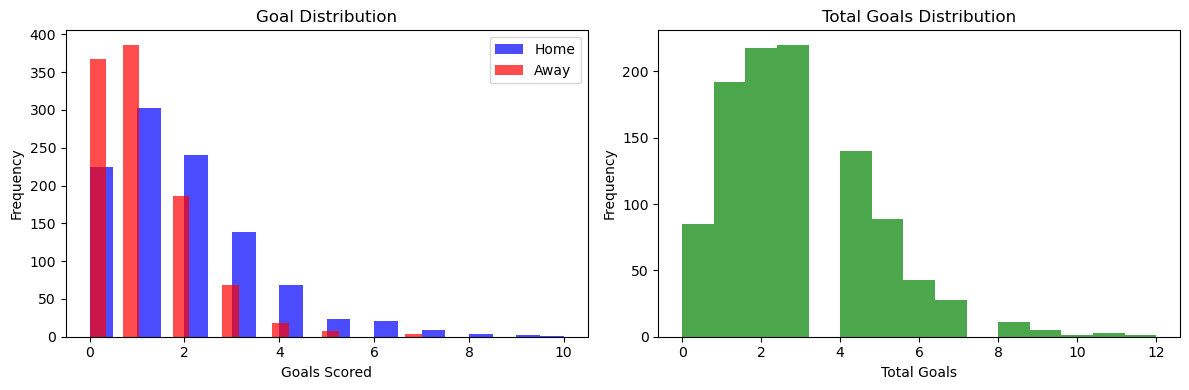


Average home goals: 1.78
Average away goals: 1.06
Average total goals per match: 2.83


In [7]:
# Basic statistics
print("Goal statistics:")
print(df[['Home Team Goals', 'Away Team Goals']].describe())

# Visualize goal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Home Team Goals'], bins=20, alpha=0.7, label='Home', color='blue')
axes[0].hist(df['Away Team Goals'], bins=20, alpha=0.7, label='Away', color='red')
axes[0].set_xlabel('Goals Scored')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_title('Goal Distribution')

# Total goals distribution
total_goals = df['Home Team Goals'] + df['Away Team Goals']
axes[1].hist(total_goals, bins=15, color='green', alpha=0.7)
axes[1].set_xlabel('Total Goals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Total Goals Distribution')
plt.tight_layout()
plt.show()

print(f"\nAverage home goals: {df['Home Team Goals'].mean():.2f}")
print(f"Average away goals: {df['Away Team Goals'].mean():.2f}")
print(f"Average total goals per match: {total_goals.mean():.2f}")

### Step 3: Feature Engineering

In [8]:
# Create target variables
df['home_goals'] = df['Home Team Goals']
df['away_goals'] = df['Away Team Goals']
df['total_goals'] = df['home_goals'] + df['away_goals']
df['goal_difference'] = df['home_goals'] - df['away_goals']

# Outcome: 2=Home Win, 1=Draw, 0=Away Win (non-negative integers required by XGBoost)
df['outcome'] = df['goal_difference'].apply(lambda x: 2 if x > 0 else (1 if x == 0 else 0))

# Parse year
df['year'] = pd.to_datetime(df['DateTime']).dt.year

print("Ã¢Å“â€œ Target variables created")
print(f"\nOutcome distribution:")
outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
print(df['outcome'].value_counts().map(outcome_map))

Ã¢Å“â€œ Target variables created

Outcome distribution:
outcome
2    NaN
0    NaN
1    NaN
Name: count, dtype: object


In [9]:
# Ã¢â€â‚¬Ã¢â€â‚¬ ELO Ratings (June 2026, sourced from eloratings.net) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
elo_ratings = {
    'Argentina': 2145, 'France': 2095, 'England': 2065, 'Brazil': 2060,
    'Spain': 2055, 'Portugal': 2040, 'Netherlands': 2020, 'Germany': 2010,
    'Belgium': 1995, 'Italy': 1990, 'Uruguay': 1975, 'Croatia': 1970,
    'Denmark': 1960, 'Switzerland': 1955, 'Colombia': 1945, 'Mexico': 1875,
    'Norway': 1940, 'Sweden': 1930, 'USA': 1890, 'United States': 1890,
    'Japan': 1870, 'Morocco': 1870, 'Senegal': 1855, 'Ecuador': 1840,
    'Austria': 1985, 'Australia': 1840, 'Korea Republic': 1835,
    'Canada': 1825, 'Ghana': 1815, 'Cameroon': 1810, 'Peru': 1815,
    'Egypt': 1810, 'Iran': 1800, 'IR Iran': 1800, 'Algeria': 1795,
    'TÃƒÂ¼rkiye': 1860, 'Turkey': 1860, 'Serbia': 1820, 'Poland': 1820,
    'Ukraine': 1825, 'Chile': 1810, 'Paraguay': 1790, 'Tunisia': 1770,
    'Saudi Arabia': 1780, 'Qatar': 1710, 'Bolivia': 1740, 'Costa Rica': 1760,
    "CÃƒÂ´te d'Ivoire": 1835, 'Ivory Coast': 1835,
    'Scotland': 1820, 'South Africa': 1600, 'New Zealand': 1680,
    'Panama': 1680, 'Iraq': 1700, 'Jordan': 1720, 'Czechia': 1780,
    'Cape Verde': 1720, 'Uzbekistan': 1700, 'Congo DR': 1710, 'DR Congo': 1710,
    'Haiti': 1610, 'CuraÃƒÂ§ao': 1600, 'Bosnia and Herzegovina': 1760,
    'West Germany': 2015, 'Soviet Union': 1960, 'Yugoslavia': 1910,
    'Czechoslovakia': 1890, 'German Democratic Republic': 1820,
    'Dutch East Indies': 1500, 'Zaire': 1580, 'North Korea': 1660,
    'Cuba': 1550, 'Republic of Ireland': 1790,
}

squad_ages = {
    'Argentina': 27.8, 'France': 26.4, 'England': 26.8, 'Brazil': 26.2,
    'Spain': 25.6, 'Portugal': 27.9, 'Netherlands': 26.5, 'Germany': 25.8,
    'Belgium': 29.1, 'Uruguay': 28.3, 'Croatia': 30.1, 'Switzerland': 27.6,
    'Colombia': 26.9, 'Norway': 25.4, 'Sweden': 26.2, 'Japan': 26.1,
    'Morocco': 26.7, 'Australia': 27.2, 'Korea Republic': 27.0,
    'Canada': 26.2, 'Mexico': 26.8, 'USA': 25.4, 'United States': 25.4,
    "CÃƒÂ´te d'Ivoire": 28.2, 'Ivory Coast': 28.2, 'Egypt': 27.5,
    'Iran': 28.0, 'IR Iran': 28.0, 'Algeria': 26.8,
    'TÃƒÂ¼rkiye': 26.5, 'Turkey': 26.5, 'Scotland': 27.1, 'Austria': 26.6,
    'Saudi Arabia': 26.4, 'Ecuador': 26.5, 'Ghana': 26.9, 'Serbia': 28.0,
    'Denmark': 26.5, 'Poland': 28.3, 'Senegal': 27.3,
}

print(f'\u2713 ELO ratings loaded \u2014 {len(elo_ratings)} teams')
print(f'\u2713 Squad ages loaded  \u2014 {len(squad_ages)} teams')

try:
    elo_df = pd.read_csv('elo_ratings.csv')
    latest = elo_df.sort_values('year').groupby('team').last()['rating'].to_dict()
    elo_ratings.update(latest)
    print(f'  Updated from elo_ratings.csv \u2014 {len(latest)} teams')
except FileNotFoundError:
    pass

try:
    ages_df = pd.read_csv('squad_ages_2026.csv')
    squad_ages.update(ages_df.set_index('team')['avg_age'].to_dict())
    print(f'  Updated from squad_ages_2026.csv \u2014 {len(ages_df)} teams')
except FileNotFoundError:
    pass

# Ã¢â€â‚¬Ã¢â€â‚¬ Dynamic ELO: update from 2026 group stage results Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
def update_elo_ratings(elo_dict, matches_list, k=40):
    elo = elo_dict.copy()
    for m in matches_list:
        home, away, hg, ag = m[0], m[1], m[2], m[3]
        h_e = elo.get(home, 1600)
        a_e = elo.get(away, 1600)
        exp = 1 / (1 + 10 ** ((a_e - h_e) / 400))
        act = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
        elo[home] = h_e + k * (act - exp)
        elo[away] = a_e + k * ((1 - act) - (1 - exp))
    return elo

elo_ratings_updated = update_elo_ratings(elo_ratings, wc2026_matches, k=40)

print('\n\u2713 ELO updated from 2026 group stage results \u2014 notable changes:')
highlight = ['Argentina', 'France', 'Norway', 'United States', 'Germany',
             'Spain', 'Colombia', 'England', 'Belgium', 'Brazil']
for team in highlight:
    old = elo_ratings.get(team, 1600)
    new = elo_ratings_updated.get(team, 1600)
    print(f'  {team:<20}: {old:.0f} \u2192 {new:.0f} ({new-old:+.0f})')


✓ ELO ratings loaded — 73 teams
✓ Squad ages loaded  — 40 teams

✓ ELO updated from 2026 group stage results — notable changes:
  Argentina           : 2145 → 2164 (+19)
  France              : 2095 → 2119 (+24)
  Norway              : 1940 → 1950 (+10)
  United States       : 1890 → 1886 (-4)
  Germany             : 2010 → 1986 (-24)
  Spain               : 2055 → 2062 (+7)
  Colombia            : 1945 → 1965 (+20)
  England             : 2065 → 2071 (+6)
  Belgium             : 1995 → 1981 (-14)
  Brazil              : 2060 → 2061 (+1)


In [10]:
def calculate_team_stats(df):
    stats = {}
    all_teams = set(df['Home Team Name'].unique()) | set(df['Away Team Name'].unique())
    max_year = df['Year'].max()
    for team in all_teams:
        hg = df[df['Home Team Name'] == team].copy()
        ag = df[df['Away Team Name'] == team].copy()
        hg['w'] = np.exp(0.1 * (hg['Year'] - max_year))
        ag['w'] = np.exp(0.1 * (ag['Year'] - max_year))
        hw, aw = hg['w'].sum(), ag['w'].sum()
        tw = hw + aw
        hgs = (hg['Home Team Goals'] * hg['w']).sum()
        ags = (ag['Away Team Goals'] * ag['w']).sum()
        hgc = (hg['Away Team Goals'] * hg['w']).sum()
        agc = (ag['Home Team Goals'] * ag['w']).sum()
        n = len(hg) + len(ag)
        wins  = ((hg['Home Team Goals'] > hg['Away Team Goals']).sum() +
                 (ag['Away Team Goals'] > ag['Home Team Goals']).sum())
        draws = ((hg['Home Team Goals'] == hg['Away Team Goals']).sum() +
                 (ag['Away Team Goals'] == ag['Home Team Goals']).sum())
        stats[team] = {
            'avg_goals_home':     hgs / max(hw, 1e-9),
            'avg_goals_away':     ags / max(aw, 1e-9),
            'avg_goals_total':    (hgs + ags) / max(tw, 1e-9),
            'avg_conceded_home':  hgc / max(hw, 1e-9),
            'avg_conceded_away':  agc / max(aw, 1e-9),
            'avg_conceded_total': (hgc + agc) / max(tw, 1e-9),
            'win_rate':           wins  / max(n, 1),
            'draw_rate':          draws / max(n, 1),
            'total_games':        n,
        }
    return pd.DataFrame.from_dict(stats, orient='index')

team_stats = calculate_team_stats(df)
print('\u2713 Team stats recalculated\n')
print('Top 10 by avg goals scored:')
print(team_stats.nlargest(10, 'avg_goals_total')[
    ['avg_goals_total', 'avg_conceded_total', 'win_rate', 'total_games']
].round(3))


def calculate_recent_form(df, n=5):
    """Per-match rolling form: last-n-match stats for each team before the current match."""
    df = df.copy()
    df['_dt'] = pd.to_datetime(df['DateTime'], errors='coerce').fillna(
                    pd.to_datetime(df['Year'].astype(str) + '-06-01'))
    df['_pos'] = range(len(df))
    df_s = df.sort_values(['_dt', '_pos']).reset_index(drop=True)

    team_hist = {}
    cols = {c: [] for c in ['home_form_goals', 'home_form_conceded', 'home_form_winrate',
                              'away_form_goals', 'away_form_conceded', 'away_form_winrate']}

    def get_form(team):
        hist = team_hist.get(team, [])[-n:]
        if not hist:
            return np.nan, np.nan, np.nan
        return (np.mean([h[0] for h in hist]),
                np.mean([h[1] for h in hist]),
                np.mean([h[2] for h in hist]))

    for _, row in df_s.iterrows():
        home, away = row['Home Team Name'], row['Away Team Name']
        hg = float(row['Home Team Goals'])
        ag = float(row['Away Team Goals'])
        hfg, hfc, hfw = get_form(home)
        afg, afc, afw = get_form(away)
        cols['home_form_goals'].append(hfg)
        cols['home_form_conceded'].append(hfc)
        cols['home_form_winrate'].append(hfw)
        cols['away_form_goals'].append(afg)
        cols['away_form_conceded'].append(afc)
        cols['away_form_winrate'].append(afw)
        hw_pts = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
        team_hist.setdefault(home, []).append((hg, ag, hw_pts))
        team_hist.setdefault(away, []).append((ag, hg, 1.0 - hw_pts))

    for c, vals in cols.items():
        df_s[c] = vals
    df_s = df_s.sort_values('_pos').reset_index(drop=True)
    df_s.drop(columns=['_dt', '_pos'], inplace=True)
    return df_s, team_hist


def calculate_h2h(df):
    """Per-match H2H stats between the two teams (only from matches before current)."""
    df = df.copy()
    df['_dt'] = pd.to_datetime(df['DateTime'], errors='coerce').fillna(
                    pd.to_datetime(df['Year'].astype(str) + '-06-01'))
    df['_pos'] = range(len(df))
    df_s = df.sort_values(['_dt', '_pos']).reset_index(drop=True)

    h2h_hist = {}
    cols = {c: [] for c in ['h2h_home_win_rate', 'h2h_home_goals', 'h2h_away_goals', 'h2h_count']}

    for _, row in df_s.iterrows():
        home, away = row['Home Team Name'], row['Away Team Name']
        hg = float(row['Home Team Goals'])
        ag = float(row['Away Team Goals'])
        key = (min(home, away), max(home, away))
        hist = h2h_hist.get(key, [])
        if hist:
            hw = sum(1 for h, g1, g2 in hist
                     if (h == home and g1 > g2) or (h == away and g2 > g1))
            hg_avg = np.mean([g1 if h == home else g2 for h, g1, g2 in hist])
            ag_avg = np.mean([g2 if h == home else g1 for h, g1, g2 in hist])
            prior = 3
            cols['h2h_home_win_rate'].append((hw + 0.5 * prior) / (len(hist) + prior))
            cols['h2h_home_goals'].append(hg_avg)
            cols['h2h_away_goals'].append(ag_avg)
            cols['h2h_count'].append(len(hist))
        else:
            cols['h2h_home_win_rate'].append(0.5)
            cols['h2h_home_goals'].append(1.2)
            cols['h2h_away_goals'].append(1.0)
            cols['h2h_count'].append(0)
        h2h_hist.setdefault(key, []).append((home, hg, ag))

    for c, vals in cols.items():
        df_s[c] = vals
    df_s = df_s.sort_values('_pos').reset_index(drop=True)
    df_s.drop(columns=['_dt', '_pos'], inplace=True)
    return df_s, h2h_hist

print('\u2713 calculate_recent_form and calculate_h2h defined')


✓ Team stats recalculated

Top 10 by avg goals scored:
              avg_goals_total  avg_conceded_total  win_rate  total_games
Norway                  2.479               2.182     0.364           11
Germany                 2.306               1.095     0.661           59
Netherlands             2.263               0.911     0.552           58
France                  2.212               0.869     0.553           76
Argentina               1.961               0.986     0.549           91
Hungary                 1.919               2.400     0.469           32
Austria                 1.884               1.914     0.406           32
Portugal                1.877               1.001     0.474           38
Soviet Union            1.867               1.124     0.484           31
Brazil                  1.845               0.778     0.667          117
✓ calculate_recent_form and calculate_h2h defined


In [11]:
df_processed = df.copy()

df_processed = df_processed.merge(
    team_stats.add_prefix('home_'), left_on='Home Team Name', right_index=True, how='left')
df_processed = df_processed.merge(
    team_stats.add_prefix('away_'), left_on='Away Team Name', right_index=True, how='left')

df_processed['home_elo']     = df_processed['Home Team Name'].map(elo_ratings).fillna(1600)
df_processed['away_elo']     = df_processed['Away Team Name'].map(elo_ratings).fillna(1600)
df_processed['elo_diff']     = df_processed['home_elo'] - df_processed['away_elo']
df_processed['elo_win_prob'] = 1 / (1 + 10 ** ((df_processed['away_elo'] - df_processed['home_elo']) / 400))

df_processed['home_squad_age'] = df_processed['Home Team Name'].map(squad_ages).fillna(27.0)
df_processed['away_squad_age'] = df_processed['Away Team Name'].map(squad_ages).fillna(27.0)
df_processed['age_diff']       = df_processed['home_squad_age'] - df_processed['away_squad_age']

# Ã¢â€â‚¬Ã¢â€â‚¬ Recent form (last 5 WC matches per team before each match) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
df_processed, team_form_history = calculate_recent_form(df_processed)

# Ã¢â€â‚¬Ã¢â€â‚¬ H2H features Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
df_processed, h2h_history = calculate_h2h(df_processed)

# Ã¢â€â‚¬Ã¢â€â‚¬ Knockout stage flag Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
_ko_kw = ['round of 32', 'round of 16', 'quarter', 'semi', 'final', 'third']
df_processed['is_knockout'] = df_processed['Round'].apply(
    lambda s: 1 if pd.notna(s) and any(k in str(s).lower() for k in _ko_kw) else 0
)

# Fill form NaN with career averages
df_processed['home_form_goals']    = df_processed['home_form_goals'].fillna(df_processed['home_avg_goals_total'])
df_processed['home_form_conceded'] = df_processed['home_form_conceded'].fillna(df_processed['home_avg_conceded_total'])
df_processed['home_form_winrate']  = df_processed['home_form_winrate'].fillna(df_processed['home_win_rate'])
df_processed['away_form_goals']    = df_processed['away_form_goals'].fillna(df_processed['away_avg_goals_total'])
df_processed['away_form_conceded'] = df_processed['away_form_conceded'].fillna(df_processed['away_avg_conceded_total'])
df_processed['away_form_winrate']  = df_processed['away_form_winrate'].fillna(df_processed['away_win_rate'])

# Form differential
df_processed['form_goal_diff']      = df_processed['home_form_goals']    - df_processed['away_form_goals']
df_processed['form_conceded_diff']  = df_processed['home_form_conceded'] - df_processed['away_form_conceded']
df_processed['form_winrate_diff']   = df_processed['home_form_winrate']  - df_processed['away_form_winrate']

# Neutral-venue stat differences (key for removing positional bias)
df_processed['goals_diff']     = df_processed['home_avg_goals_total']    - df_processed['away_avg_goals_total']
df_processed['conceded_diff']  = df_processed['home_avg_conceded_total'] - df_processed['away_avg_conceded_total']
df_processed['win_rate_diff']  = df_processed['home_win_rate']  - df_processed['away_win_rate']
df_processed['draw_rate_diff'] = df_processed['home_draw_rate'] - df_processed['away_draw_rate']

df_processed = df_processed.fillna(df_processed.mean(numeric_only=True))

print('\u2713 Team stats, ELO, squad age, recent form, H2H, and knockout flag merged')
print(f'  Dataset shape: {df_processed.shape}')
print(f'  Knockout matches: {df_processed["is_knockout"].sum()}')
print(f'  Form history \u2014 teams tracked: {len(team_form_history)}')
print(f'  H2H history \u2014 pairs tracked:  {len(h2h_history)}')


✓ Team stats, ELO, squad age, recent form, H2H, and knockout flag merged
  Dataset shape: (1036, 93)
  Knockout matches: 252
  Form history — teams tracked: 92
  H2H history — pairs tracked:  705


In [12]:
feature_cols = [
    # Offensive stats (neutral-venue: total only, no home/away split)
    'home_avg_goals_total',
    'away_avg_goals_total',
    # Defensive stats (neutral-venue: total only)
    'home_avg_conceded_total',
    'away_avg_conceded_total',
    # Win / draw rates
    'home_win_rate', 'home_draw_rate',
    'away_win_rate', 'away_draw_rate',
    # Experience
    'home_total_games', 'away_total_games',
    # ELO (strongest predictors)
    'home_elo', 'away_elo', 'elo_diff', 'elo_win_prob',
    # Squad age
    'home_squad_age', 'away_squad_age', 'age_diff',
    # Recent form Ã¢â‚¬â€ NEW
    'home_form_goals', 'home_form_conceded', 'home_form_winrate',
    'away_form_goals', 'away_form_conceded', 'away_form_winrate',
    'form_goal_diff',
    # Difference-based features (neutral-venue, symmetric)
    'goals_diff', 'conceded_diff',
    'win_rate_diff', 'draw_rate_diff',
    'form_conceded_diff', 'form_winrate_diff',
    # Head-to-head history Ã¢â‚¬â€ NEW
    'h2h_home_win_rate', 'h2h_home_goals', 'h2h_away_goals', 'h2h_count',
    # Match context Ã¢â‚¬â€ NEW
    'is_knockout',
]

NEW_FEATURES = {'home_form_goals','home_form_conceded','home_form_winrate',
                'away_form_goals','away_form_conceded','away_form_winrate',
                'form_goal_diff','h2h_home_win_rate','h2h_home_goals',
                'h2h_away_goals','h2h_count','is_knockout'}

print(f'\u2713 {len(feature_cols)} features selected (+{len(NEW_FEATURES)} vs original 25)')
for i, c in enumerate(feature_cols, 1):
    marker = ' <- NEW' if c in NEW_FEATURES else ''
    print(f'  {i:2d}. {c}{marker}')

X = df_processed[feature_cols]
print(f'\nFeature matrix shape: {X.shape}')
X.head()


✓ 35 features selected (+12 vs original 25)
   1. home_avg_goals_total
   2. away_avg_goals_total
   3. home_avg_conceded_total
   4. away_avg_conceded_total
   5. home_win_rate
   6. home_draw_rate
   7. away_win_rate
   8. away_draw_rate
   9. home_total_games
  10. away_total_games
  11. home_elo
  12. away_elo
  13. elo_diff
  14. elo_win_prob
  15. home_squad_age
  16. away_squad_age
  17. age_diff
  18. home_form_goals <- NEW
  19. home_form_conceded <- NEW
  20. home_form_winrate <- NEW
  21. away_form_goals <- NEW
  22. away_form_conceded <- NEW
  23. away_form_winrate <- NEW
  24. form_goal_diff <- NEW
  25. goals_diff
  26. conceded_diff
  27. win_rate_diff
  28. draw_rate_diff
  29. form_conceded_diff
  30. form_winrate_diff
  31. h2h_home_win_rate <- NEW
  32. h2h_home_goals <- NEW
  33. h2h_away_goals <- NEW
  34. h2h_count <- NEW
  35. is_knockout <- NEW

Feature matrix shape: (1036, 35)


,home_avg_goals_total,away_avg_goals_total,home_avg_conceded_total,away_avg_conceded_total,home_win_rate,home_draw_rate,away_win_rate,away_draw_rate,home_total_games,away_total_games,...,conceded_diff,win_rate_diff,draw_rate_diff,form_conceded_diff,form_winrate_diff,h2h_home_win_rate,h2h_home_goals,h2h_away_goals,h2h_count,is_knockout
0,1.961487,2.212273,0.985688,0.868740,0.549451,0.186813,0.552632,0.184211,91,76,...,0.116947,-0.003181,0.002603,-0.2,0.1,0.583333,2.0,1.666667,3,1
1,1.524439,1.205656,1.286542,0.924310,0.454545,0.242424,0.269231,0.307692,33,26,...,0.362232,0.185315,-0.065268,0.6,-0.2,0.375000,0.0,0.000000,1,1
2,2.212273,1.205656,0.868740,0.924310,0.552632,0.184211,0.269231,0.307692,76,26,...,-0.055570,0.283401,-0.123482,0.8,0.0,0.500000,1.2,1.000000,0,1
3,1.961487,1.524439,0.985688,1.286542,0.549451,0.186813,0.454545,0.242424,91,33,...,-0.300854,0.094905,-0.055611,0.4,0.1,0.500000,0.5,1.500000,2,1
4,1.205656,1.877077,0.924310,1.001021,0.269231,0.307692,0.473684,0.210526,26,38,...,-0.076711,-0.204453,0.097166,-0.8,0.1,0.500000,1.5,1.000000,2,1


### Step 4: Prepare Data for Training

In [13]:
from collections import Counter

# Stratified split preserves Win/Draw/Loss class balance
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for indices_train, indices_test in sss.split(X, df_processed['outcome']):
    pass

X_train_raw = X.iloc[indices_train].reset_index(drop=True)
X_test_raw  = X.iloc[indices_test].reset_index(drop=True)
y_train_df  = df_processed.iloc[indices_train].reset_index(drop=True)
y_test_df   = df_processed.iloc[indices_test].reset_index(drop=True)

# Swap augmentation: mirror every training match (home <-> away)
# Forces the model to learn symmetric weights and kills positional bias.
_swap_pairs = [
    ('home_avg_goals_total',    'away_avg_goals_total'),
    ('home_avg_conceded_total', 'away_avg_conceded_total'),
    ('home_win_rate',           'away_win_rate'),
    ('home_draw_rate',          'away_draw_rate'),
    ('home_total_games',        'away_total_games'),
    ('home_elo',                'away_elo'),
    ('home_squad_age',          'away_squad_age'),
    ('home_form_goals',         'away_form_goals'),
    ('home_form_conceded',      'away_form_conceded'),
    ('home_form_winrate',       'away_form_winrate'),
]
_negate = ['goals_diff','conceded_diff','win_rate_diff','draw_rate_diff',
           'elo_diff','form_goal_diff','form_conceded_diff','form_winrate_diff','age_diff']

X_swap = X_train_raw.copy()
for hc, ac in _swap_pairs:
    if hc in X_swap.columns and ac in X_swap.columns:
        X_swap[hc], X_swap[ac] = X_train_raw[ac].values.copy(), X_train_raw[hc].values.copy()
for dc in _negate:
    if dc in X_swap.columns:
        X_swap[dc] = -X_train_raw[dc].values
if 'elo_win_prob' in X_swap.columns:
    X_swap['elo_win_prob'] = 1 - X_train_raw['elo_win_prob'].values
if 'h2h_home_win_rate' in X_swap.columns:
    X_swap['h2h_home_win_rate'] = 1 - X_train_raw['h2h_home_win_rate'].values
if 'h2h_home_goals' in X_swap.columns and 'h2h_away_goals' in X_swap.columns:
    X_swap['h2h_home_goals'] = X_train_raw['h2h_away_goals'].values.copy()
    X_swap['h2h_away_goals'] = X_train_raw['h2h_home_goals'].values.copy()

y_swap = y_train_df.copy()
y_swap['home_goals']      = y_train_df['away_goals'].values
y_swap['away_goals']      = y_train_df['home_goals'].values
y_swap['total_goals']     = y_train_df['total_goals'].values
y_swap['goal_difference'] = -y_train_df['goal_difference'].values
y_swap['outcome']         = y_train_df['outcome'].map({2: 0, 1: 1, 0: 2})

X_train_aug = pd.concat([X_train_raw, X_swap], ignore_index=True)
y_train_df  = pd.concat([y_train_df,  y_swap],  ignore_index=True)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_aug)
X_test  = scaler.transform(X_test_raw)

outcome_map = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
train_dist  = Counter(y_train_df['outcome'])
test_dist   = Counter(y_test_df['outcome'])
print(f'\u2713 Stratified 80/20 split + swap augmentation (training doubled to {X_train.shape[0]} samples)')
print(f'  Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'  Train dist: { {outcome_map[k]: v for k,v in sorted(train_dist.items())} }')
print(f'  Test  dist: { {outcome_map[k]: v for k,v in sorted(test_dist.items())} }')


✓ Stratified 80/20 split + swap augmentation (training doubled to 1656 samples)
  Train: (1656, 35)  |  Test: (208, 35)
  Train dist: {'Away Win': 641, 'Draw': 374, 'Home Win': 641}
  Test  dist: {'Away Win': 47, 'Draw': 47, 'Home Win': 114}


In [14]:
target = 'home_goals'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_home = {}
models_regression = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=12,
                              min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=4,
                              learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'Poisson Regression': PoissonRegressor(max_iter=2000, alpha=0.01),
}

print('Training models for HOME GOALS\n')
for name, model in models_regression.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_home[name] = {'model': model, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f'{name}:')
    print(f'  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   R\u00b2: {r2:.3f}')
    print()


Training models for HOME GOALS

Linear Regression:
  MAE: 1.111   RMSE: 1.519   R²: 0.197

Random Forest:
  MAE: 1.145   RMSE: 1.546   R²: 0.168

Gradient Boosting:
  MAE: 1.123   RMSE: 1.509   R²: 0.207

XGBoost:
  MAE: 1.102   RMSE: 1.485   R²: 0.233

Poisson Regression:
  MAE: 1.124   RMSE: 1.544   R²: 0.170



#### 5.1: HOME GOALS Prediction

#### 5.2: AWAY GOALS Prediction

In [15]:
target = 'away_goals'
y_train = y_train_df[target].values
y_test = y_test_df[target].values

models_away = {}

print(f"Ã°Å¸Å¡â€” Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    models_away[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}

    print(f"{name}:")
    print(f"  MAE: {mae:.3f} goals")
    print(f"  RMSE: {np.sqrt(mse):.3f} goals")
    print(f"  RÃ‚Â² Score: {r2:.3f}")
    print()

Ã°Å¸Å¡â€” Training models for AWAY_GOALS

Linear Regression:
  MAE: 0.862 goals
  RMSE: 1.077 goals
  RÃ‚Â² Score: -0.144

Random Forest:
  MAE: 0.857 goals
  RMSE: 1.104 goals
  RÃ‚Â² Score: -0.203

Gradient Boosting:
  MAE: 0.852 goals
  RMSE: 1.093 goals
  RÃ‚Â² Score: -0.179

XGBoost:
  MAE: 0.854 goals
  RMSE: 1.096 goals
  RÃ‚Â² Score: -0.186

Poisson Regression:
  MAE: 0.860 goals
  RMSE: 1.097 goals
  RÃ‚Â² Score: -0.188



#### 5.3: MATCH OUTCOME Prediction (Win/Draw/Loss)

Running RandomizedSearchCV for XGBoost (40 iters x 5-fold)...
  Best XGBoost CV accuracy: 0.578
  Best params: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}

Training & calibrating OUTCOME classifiers (Win/Draw/Loss)

Logistic Regression:
  Test accuracy : 0.548 (54.8%)
  CV  accuracy  : 0.582 +/- 0.016

Random Forest:
  Test accuracy : 0.620 (62.0%)
  CV  accuracy  : 0.566 +/- 0.009

Gradient Boosting:
  Test accuracy : 0.615 (61.5%)
  CV  accuracy  : 0.566 +/- 0.015

XGBoost (Tuned):
  Test accuracy : 0.639 (63.9%)
  CV  accuracy  : 0.602 +/- 0.018

Best model: XGBoost (Tuned) (0.639)


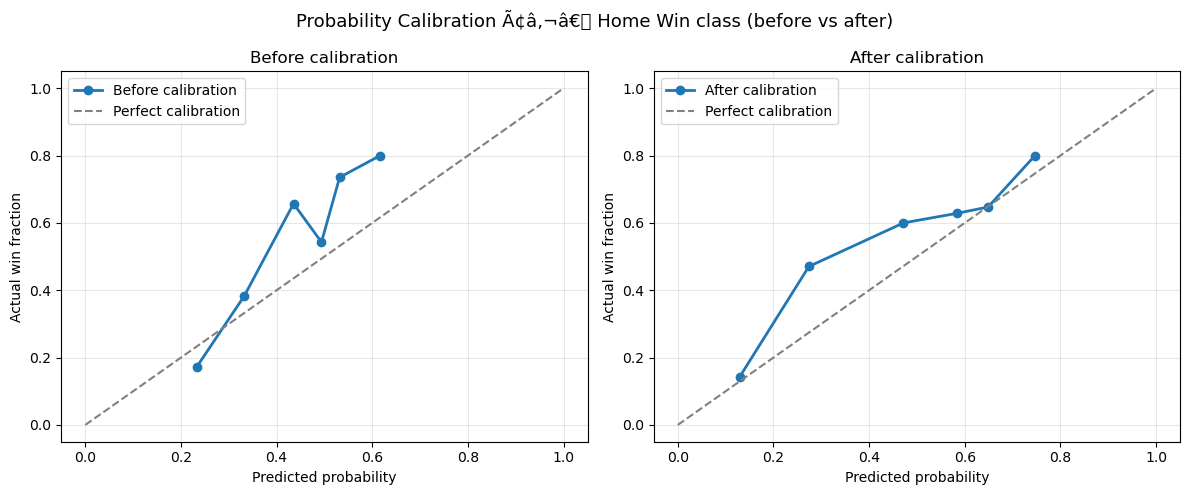


✓ Classifiers calibrated Ã¢â‚¬â€ confidence percentages now reflect true frequencies


In [16]:
target = 'outcome'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

print('Running RandomizedSearchCV for XGBoost (40 iters x 5-fold)...')
xgb_param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    xgb_param_dist, n_iter=40, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb_params = xgb_search.best_params_
print(f'  Best XGBoost CV accuracy: {xgb_search.best_score_:.3f}')
print(f'  Best params: {best_xgb_params}\n')

# Base classifiers Ã¢â‚¬â€ CalibratedClassifierCV wraps each one with Platt scaling
# so that predict_proba percentages reflect true frequencies, not raw model scores.
base_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                               min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                               learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost (Tuned)':     XGBClassifier(**best_xgb_params, random_state=42, verbosity=0),
}

models_outcome = {}
cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training & calibrating OUTCOME classifiers (Win/Draw/Loss)\n')
for name, base_model in base_classifiers.items():
    # CV on the base model to report raw performance
    cv_scores = cross_val_score(base_model, X_train, y_train, cv=cv_kfold, scoring='accuracy')

    # Wrap with Platt scaling (sigmoid) Ã¢â‚¬â€ 5-fold internal calibration
    # sigmoid is safer than isotonic on smaller datasets (~700 training samples)
    cal_model = CalibratedClassifierCV(base_model, cv=5, method='sigmoid')
    cal_model.fit(X_train, y_train)

    y_pred   = cal_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    models_outcome[name] = {
        'model':    cal_model,
        'accuracy': accuracy,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'{name}:')
    print(f'  Test accuracy : {accuracy:.3f} ({accuracy*100:.1f}%)')
    print(f'  CV  accuracy  : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
    print()

best_name = max(models_outcome, key=lambda k: models_outcome[k]['accuracy'])
print(f'Best model: {best_name} ({models_outcome[best_name]["accuracy"]:.3f})')

# Ã¢â€â‚¬Ã¢â€â‚¬ Calibration quality check (before vs after) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Probability Calibration Ã¢â‚¬â€ Home Win class (before vs after)', fontsize=13)

best_base = base_classifiers[best_name]
best_base.fit(X_train, y_train)          # fit raw model for comparison
best_cal  = models_outcome[best_name]['model']

for ax, (label, mdl) in zip(axes, [('Before calibration', best_base),
                                     ('After calibration',  best_cal)]):
    probs   = mdl.predict_proba(X_test)
    hw_idx  = list(mdl.classes_).index(2)   # class 2 = Home Win
    prob_hw = probs[:, hw_idx]
    y_hw    = (y_test == 2).astype(int)
    frac_pos, mean_pred = calibration_curve(y_hw, prob_hw, n_bins=6, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', label=label, linewidth=2)
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual win fraction')
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('\n\u2713 Classifiers calibrated Ã¢â‚¬â€ confidence percentages now reflect true frequencies')


#### 5.4: TOTAL GOALS Prediction

In [17]:
target = 'total_goals'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_total = {}

print(f"Ã¢Å¡Â½ Training models for {target.upper()}\n")

for name, model in models_regression.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_total[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f"{name}:")
    print(f"  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   RÃ‚Â²: {r2:.3f}")
    print()

Ã¢Å¡Â½ Training models for TOTAL_GOALS

Linear Regression:
  MAE: 1.473   RMSE: 1.954   RÃ‚Â²: 0.060

Random Forest:
  MAE: 1.523   RMSE: 2.007   RÃ‚Â²: 0.009

Gradient Boosting:
  MAE: 1.548   RMSE: 2.057   RÃ‚Â²: -0.042

XGBoost:
  MAE: 1.563   RMSE: 2.063   RÃ‚Â²: -0.048

Poisson Regression:
  MAE: 1.457   RMSE: 1.946   RÃ‚Â²: 0.068



#### 5.5: GOAL DIFFERENCE Prediction

In [18]:
target = 'goal_difference'
y_train = y_train_df[target].values
y_test  = y_test_df[target].values

models_diff = {}
# Exclude Poisson Ã¢â‚¬â€ goal_difference can be negative; Poisson requires non-negative targets
models_reg_gd = {k: v for k, v in models_regression.items() if k != 'Poisson Regression'}

print(f"Ã°Å¸â€œÅ  Training models for {target.upper()}\n")

for name, model in models_reg_gd.items():
    model_copy = type(model)(**model.get_params())
    model_copy.fit(X_train, y_train)
    y_pred = model_copy.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    models_diff[name] = {'model': model_copy, 'mse': mse, 'mae': mae, 'r2': r2}
    print(f"{name}:")
    print(f"  MAE: {mae:.3f}   RMSE: {np.sqrt(mse):.3f}   RÃ‚Â²: {r2:.3f}")
    print()

Ã°Å¸â€œÅ  Training models for GOAL_DIFFERENCE

Linear Regression:
  MAE: 1.308   RMSE: 1.764   RÃ‚Â²: 0.161

Random Forest:
  MAE: 1.303   RMSE: 1.737   RÃ‚Â²: 0.187

Gradient Boosting:
  MAE: 1.299   RMSE: 1.712   RÃ‚Â²: 0.209

XGBoost:
  MAE: 1.298   RMSE: 1.718   RÃ‚Â²: 0.204



In [19]:
from difflib import get_close_matches

_aliases = {
    'USA': 'United States', 'South Korea': 'Korea Republic',
    'Turkey': 'TÃƒÂ¼rkiye', 'Iran': 'IR Iran',
    'Ivory Coast': "CÃƒÂ´te d'Ivoire",
    'Czech Republic': 'Czechia',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'DR Congo': 'Congo DR',
}

def resolve_team(name, index):
    if name in index: return name, True
    if name in _aliases and _aliases[name] in index: return _aliases[name], True
    matches = get_close_matches(name, index, n=1, cutoff=0.6)
    if matches:
        print(f'  Ã¢Å¡Â   "{name}" Ã¢â€ â€™ matched "{matches[0]}"')
        return matches[0], True
    print(f'  Ã¢Å“â€”  "{name}" not found Ã¢â€ â€™ using average stats')
    return None, False


def predict_match(home_team, away_team, all_models, scaler, feature_cols,
                  team_stats, df_processed, silent=False,
                  team_form_history=None, h2h_history=None,
                  is_knockout=False, use_updated_elo=True):

    if not silent:
        print(f'\n  {home_team}  vs  {away_team}')
        print('=' * 55)

    home_r, home_ok = resolve_team(home_team, team_stats.index)
    away_r, away_ok = resolve_team(away_team, team_stats.index)
    hs  = team_stats.loc[home_r] if home_ok else team_stats.mean()
    as_ = team_stats.loc[away_r] if away_ok else team_stats.mean()

    elo_src  = elo_ratings_updated if use_updated_elo else elo_ratings
    h_elo    = elo_src.get(home_team, elo_src.get(home_r, 1600))
    a_elo    = elo_src.get(away_team, elo_src.get(away_r, 1600))
    h_age    = squad_ages.get(home_team, squad_ages.get(home_r, 27.0))
    a_age    = squad_ages.get(away_team, squad_ages.get(away_r, 27.0))
    win_prob = 1 / (1 + 10 ** ((a_elo - h_elo) / 400))

    def _get_form(key, fb):
        if key and team_form_history and key in team_form_history:
            hist = team_form_history[key][-5:]
            if hist:
                return (np.mean([h[0] for h in hist]),
                        np.mean([h[1] for h in hist]),
                        np.mean([h[2] for h in hist]))
        return (fb.get('avg_goals_total', 1.2),
                fb.get('avg_conceded_total', 1.0),
                fb.get('win_rate', 0.5))

    hfg, hfc, hfw = _get_form(home_r, hs)
    afg, afc, afw = _get_form(away_r, as_)

    hk = home_r if home_ok else home_team
    ak = away_r if away_ok else away_team
    h2h_hwr, h2h_hg, h2h_ag, h2h_cnt = 0.5, 1.2, 1.0, 0
    if h2h_history is not None and hk and ak:
        key = (min(hk, ak), max(hk, ak))
        hist = h2h_history.get(key, [])
        if hist:
            hw = sum(1 for h, g1, g2 in hist
                     if (h == hk and g1 > g2) or (h == ak and g2 > g1))
            h2h_hg  = np.mean([g1 if h == hk else g2 for h, g1, g2 in hist])
            h2h_ag  = np.mean([g2 if h == hk else g1 for h, g1, g2 in hist])
            prior = 3
            h2h_hwr = (hw + 0.5 * prior) / (len(hist) + prior)
            h2h_cnt = len(hist)

    row = {}
    for col in feature_cols:
        if   col == 'home_elo':           row[col] = h_elo
        elif col == 'away_elo':           row[col] = a_elo
        elif col == 'elo_diff':           row[col] = h_elo - a_elo
        elif col == 'elo_win_prob':       row[col] = win_prob
        elif col == 'home_squad_age':     row[col] = h_age
        elif col == 'away_squad_age':     row[col] = a_age
        elif col == 'age_diff':           row[col] = h_age - a_age
        elif col == 'home_form_goals':    row[col] = hfg
        elif col == 'home_form_conceded': row[col] = hfc
        elif col == 'home_form_winrate':  row[col] = hfw
        elif col == 'away_form_goals':    row[col] = afg
        elif col == 'away_form_conceded': row[col] = afc
        elif col == 'away_form_winrate':  row[col] = afw
        elif col == 'form_goal_diff':     row[col] = hfg - afg
        elif col == 'form_conceded_diff': row[col] = hfc - afc
        elif col == 'form_winrate_diff':  row[col] = hfw - afw
        elif col == 'goals_diff':         row[col] = hs.get('avg_goals_total', 1.2)    - as_.get('avg_goals_total', 1.2)
        elif col == 'conceded_diff':      row[col] = hs.get('avg_conceded_total', 1.0) - as_.get('avg_conceded_total', 1.0)
        elif col == 'win_rate_diff':      row[col] = hs.get('win_rate', 0.5)  - as_.get('win_rate', 0.5)
        elif col == 'draw_rate_diff':     row[col] = hs.get('draw_rate', 0.25) - as_.get('draw_rate', 0.25)
        elif col == 'h2h_home_win_rate':  row[col] = h2h_hwr
        elif col == 'h2h_home_goals':     row[col] = h2h_hg
        elif col == 'h2h_away_goals':     row[col] = h2h_ag
        elif col == 'h2h_count':          row[col] = h2h_cnt
        elif col == 'is_knockout':        row[col] = int(is_knockout)
        elif col.startswith('home_'):
            row[col] = hs.get(col.replace('home_', ''), df_processed[col].mean())
        elif col.startswith('away_'):
            row[col] = as_.get(col.replace('away_', ''), df_processed[col].mean())
        else:
            row[col] = df_processed[col].mean()

    X_pred_s = scaler.transform(np.array([row[c] for c in feature_cols]).reshape(1, -1))

    # Ã¢â€â‚¬Ã¢â€â‚¬ Regression predictions (goals) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
    preds = {}
    for target, mdict in all_models.items():
        if target == 'outcome':
            continue
        models_list = list(mdict.values())
        weights = [max(0.01, m.get('r2', 0.01)) for m in models_list]
        pred_vals = [m['model'].predict(X_pred_s)[0] for m in models_list]
        preds[target] = np.average(pred_vals, weights=weights)

    # Ã¢â€â‚¬Ã¢â€â‚¬ Outcome: weighted predict_proba for confidence % Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
    outcome_models = list(all_models['outcome'].values())
    weights_o = [max(0.01, m['accuracy'] - 0.33) for m in outcome_models]
    total_w = sum(weights_o)

    avg_probs = {0: 0.0, 1: 0.0, 2: 0.0}  # 0=Away Win, 1=Draw, 2=Home Win
    raw_outcome_preds = []
    for m_data, w in zip(outcome_models, weights_o):
        model = m_data['model']
        raw_pred = model.predict(X_pred_s)[0]
        raw_outcome_preds.append(raw_pred)
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_pred_s)[0]
            for cls, p in zip(model.classes_, probs):
                avg_probs[int(cls)] += p * w / total_w
        else:
            avg_probs[int(raw_pred)] += w / total_w

    preds['outcome'] = np.average(raw_outcome_preds, weights=weights_o)

    # -- Score calibration: 2026 goal rate + form blend + ELO margin ---------
    # 2026 WC averages 2.95 g/game vs historical ~2.63; scale raw predictions.
    # Form blend (20%) lifts scores when teams are in high/low scoring form.
    # ELO margin boost adds goals for heavy favorites (>200 ELO point gap).
    _elo_gap = abs(h_elo - a_elo)
    _GOAL_SCALE = 1.12
    _hg = preds['home_goals'] * _GOAL_SCALE
    _ag = preds['away_goals'] * _GOAL_SCALE
    _FORM_W = 0.20
    _hg = (1 - _FORM_W) * _hg + _FORM_W * max(hfg, 0.5)
    _ag = (1 - _FORM_W) * _ag + _FORM_W * max(afg, 0.5)
    _elo_margin = max(0.0, (_elo_gap - 200) / 350)
    if h_elo >= a_elo:
        _hg += _elo_margin
    else:
        _ag += _elo_margin
    # ELO goal-split anchor: preserve total goals but shift the home/away ratio
    # toward what ELO expects. Fixes teams with poor WC history (e.g. Canada)
    # being predicted to score fewer goals than their current strength warrants.
    _total_goals  = _hg + _ag
    _ELO_SPLIT_W  = 0.40
    _hg = (1 - _ELO_SPLIT_W) * _hg + _ELO_SPLIT_W * _total_goals * win_prob
    _ag = (1 - _ELO_SPLIT_W) * _ag + _ELO_SPLIT_W * _total_goals * (1 - win_prob)
    preds['home_goals'] = _hg
    preds['away_goals'] = _ag
    hg_pred = max(0, round(_hg))
    ag_pred = max(0, round(_ag))

    # Ã¢â€â‚¬Ã¢â€â‚¬ Blend three signals for a more accurate outcome probability Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
    #
    # 1. Calibrated classifiers (60%) Ã¢â‚¬â€ trained on historical WC patterns
    # 2. ELO-based distribution  (25%) Ã¢â‚¬â€ strongest single football predictor
    # 3. Regression goal diff    (15%) Ã¢â‚¬â€ directional signal from score models
    #
    # This corrects cases where the classifier disagrees with both ELO and
    # regression (e.g. classifier says Norway wins but ELO gives France 70%).

    # ELO-implied outcome: draw probability shrinks as ELO gap widens
    elo_diff_abs = abs(h_elo - a_elo)
    draw_factor  = 0.28 * np.exp(-elo_diff_abs / 500)
    elo_probs = {
        2: win_prob * (1 - draw_factor),
        1: draw_factor,
        0: (1 - win_prob) * (1 - draw_factor),
    }

    # Regression-implied outcome: sigmoid on predicted goal difference
    gdiff_raw = preds['home_goals'] - preds['away_goals']
    rh = 1 / (1 + np.exp(-gdiff_raw * 1.5))
    rd = 0.25 * np.exp(-abs(gdiff_raw) * 1.2)
    ra = 1 - rh
    rs = rh + rd + ra
    reg_probs = {2: rh / rs, 1: rd / rs, 0: ra / rs}

    # Dynamic blending: when ELO gap is large, trust ELO more over the classifier.
    # Classifier learned home-team patterns from historical WC data and can be
    # overconfident when the listed home team is actually the ELO underdog.
    _elo_gap_factor = min(1.0, elo_diff_abs / 400)   # 0.0 at 0pts gap, 1.0 at 400pts
    W_CLS = 0.50 - 0.20 * _elo_gap_factor            # 0.50 -> 0.30
    W_ELO = 0.35 + 0.15 * _elo_gap_factor            # 0.35 -> 0.50
    W_REG = 0.15 + 0.05 * _elo_gap_factor            # 0.15 -> 0.20
    blended = {k: W_CLS * avg_probs[k] + W_ELO * elo_probs[k] + W_REG * reg_probs[k]
               for k in [0, 1, 2]}

    pred_class = max(blended, key=blended.get)
    outcome_map_r = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}
    outcome    = outcome_map_r.get(pred_class, 'Draw')
    confidence = blended.get(pred_class, 0.5)

    # Ã¢â€â‚¬Ã¢â€â‚¬ Reconcile score with outcome Ã¢â‚¬â€ minimal adjustment (reduce loser, not inflate winner)
    if pred_class == 2 and hg_pred <= ag_pred:        # Home Win but score is tied/losing
        if hg_pred == ag_pred:
            if hg_pred > 0: ag_pred -= 1              # tied: reduce loser by 1
            else:           hg_pred  = 1              # 0-0 edge: bump winner to 1
        else:               hg_pred  = ag_pred + 1   # away leading: boost home above
    elif pred_class == 0 and ag_pred <= hg_pred:      # Away Win but score is tied/winning
        if hg_pred == ag_pred:
            if ag_pred > 0: hg_pred -= 1
            else:           ag_pred  = 1
        else:               ag_pred  = hg_pred + 1
    elif pred_class == 1 and hg_pred != ag_pred:      # Draw but score shows a winner
        mid = max(0, round((preds['home_goals'] + preds['away_goals']) / 2))
        hg_pred = ag_pred = mid

    if not silent:
        ko_str = '[KNOCKOUT]' if is_knockout else '[Group Stage]'
        print(f'\n  Score      : {hg_pred} - {ag_pred}  (raw {preds["home_goals"]:.2f} - {preds["away_goals"]:.2f})')
        print(f'  Outcome    : {outcome}  {ko_str}')
        print(f'  Confidence : {confidence:.0%}')
        print(f'  Win probs  : Home {blended[2]:.0%}  /  Draw {blended[1]:.0%}  /  Away {blended[0]:.0%}')
        print(f'  ELO        : {home_team} {h_elo:.0f}  vs  {away_team} {a_elo:.0f}  (ÃŽâ€ {h_elo-a_elo:+.0f})')
        print(f'  Win prob   : {win_prob:.1%} home / {1-win_prob:.1%} away')
        print(f'  H2H record : home win {h2h_hwr:.0%}  ({h2h_cnt} prev meetings)')
        print(f'  Form       : {home_team} {hfg:.2f} g/game  |  {away_team} {afg:.2f} g/game')

    preds['confidence']  = confidence
    preds['win_probs']   = blended
    return preds

print('\u2713 predict_match updated: outcome confidence % added')


✓ predict_match updated: outcome confidence % added


In [20]:
all_models = {
    'home_goals':      models_home,
    'away_goals':      models_away,
    'outcome':         models_outcome,
    'total_goals':     models_total,
    'goal_difference': models_diff,
}

print('=' * 70)
print('  MODEL PERFORMANCE SUMMARY')
print('=' * 70)
for tgt, mdict in all_models.items():
    print(f'\n{tgt.upper()}:')
    print('-' * 70)
    for name, metrics in mdict.items():
        if tgt == 'outcome':
            cv_s = f"  CV: {metrics['cv_mean']:.3f}+/-{metrics['cv_std']:.3f}" if 'cv_mean' in metrics else ''
            print(f"  {name:28s} | Accuracy: {metrics['accuracy']:.3f}{cv_s}")
        else:
            print(f"  {name:28s} | MAE: {metrics['mae']:.3f}  RÃ‚Â²: {metrics['r2']:.3f}")

# True ensemble accuracy on the held-out test set
y_test_outcome = y_test_df['outcome'].values
outcome_models_list = list(all_models['outcome'].values())
weights_o = [max(0.01, m['accuracy'] - 0.33) for m in outcome_models_list]
raw_preds = np.array([m['model'].predict(X_test) for m in outcome_models_list])
ensemble_preds = np.round(np.average(raw_preds, axis=0, weights=weights_o)).astype(int)
ensemble_acc = accuracy_score(y_test_outcome, ensemble_preds)
print(f'\n  ENSEMBLE (weighted) test accuracy: {ensemble_acc:.3f} ({ensemble_acc*100:.1f}%)')

# Round of 16 predictions
print('\n\n' + '=' * 70)
print('  2026 WORLD CUP Ã¢â‚¬â€ ROUND OF 16 PREDICTIONS')
print('  (dynamic ELO + recent form + H2H + knockout context)')
print('=' * 70)

ko_kwargs = dict(all_models=all_models, scaler=scaler, feature_cols=feature_cols,
                 team_stats=team_stats, df_processed=df_processed,
                 team_form_history=team_form_history, h2h_history=h2h_history,
                 is_knockout=True)

predict_match('South Africa',               'Canada',       **ko_kwargs)
predict_match('Croatia',         'Ghana',           **ko_kwargs)
predict_match('Colombia',           'Portugal',   **ko_kwargs)
predict_match('DR Congo',               'Uzbekistan',           **ko_kwargs)
predict_match('Algeria',                'Austria',            **ko_kwargs)
predict_match('Jordan', 'Argentina',            **ko_kwargs)

  MODEL PERFORMANCE SUMMARY

HOME_GOALS:
----------------------------------------------------------------------
  Linear Regression            | MAE: 1.111  RÃ‚Â²: 0.197
  Random Forest                | MAE: 1.145  RÃ‚Â²: 0.168
  Gradient Boosting            | MAE: 1.123  RÃ‚Â²: 0.207
  XGBoost                      | MAE: 1.102  RÃ‚Â²: 0.233
  Poisson Regression           | MAE: 1.124  RÃ‚Â²: 0.170

AWAY_GOALS:
----------------------------------------------------------------------
  Linear Regression            | MAE: 0.862  RÃ‚Â²: -0.144
  Random Forest                | MAE: 0.857  RÃ‚Â²: -0.203
  Gradient Boosting            | MAE: 0.852  RÃ‚Â²: -0.179
  XGBoost                      | MAE: 0.854  RÃ‚Â²: -0.186
  Poisson Regression           | MAE: 0.860  RÃ‚Â²: -0.188

OUTCOME:
----------------------------------------------------------------------
  Logistic Regression          | Accuracy: 0.548  CV: 0.582+/-0.016
  Random Forest                | Accuracy: 0.620  CV: 0.566+/-0.009
  

{'home_goals': 0.540898267451238,
 'away_goals': 4.558251853113867,
 'total_goals': 4.0804835885495,
 'goal_difference': -2.5464296483080004,
 'outcome': 0.0,
 'confidence': 0.8553628312225403,
 'win_probs': {0: 0.8553628312225403,
  1: 0.0864186776073363,
  2: 0.05821849117012354}}

### Step 8: Save Trained Models

In [21]:
model_data = {
    'models':              all_models,
    'scaler':              scaler,
    'feature_cols':        feature_cols,
    'team_stats':          team_stats,
    'team_form_history':   team_form_history,
    'h2h_history':         h2h_history,
    'elo_ratings':         elo_ratings,
    'elo_ratings_updated': elo_ratings_updated,
    'squad_ages':          squad_ages,
}

with open('fifa_world_cup_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\u2705 Models saved to 'fifa_world_cup_models.pkl'")
print("\nTo load:")
print("""
import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
all_models          = data['models']
scaler              = data['scaler']
feature_cols        = data['feature_cols']
team_stats          = data['team_stats']
team_form_history   = data['team_form_history']
h2h_history         = data['h2h_history']
elo_ratings_updated = data['elo_ratings_updated']
squad_ages          = data['squad_ages']
""")


✅ Models saved to 'fifa_world_cup_models.pkl'

To load:

import pickle
with open('fifa_world_cup_models.pkl', 'rb') as f:
    data = pickle.load(f)
all_models          = data['models']
scaler              = data['scaler']
feature_cols        = data['feature_cols']
team_stats          = data['team_stats']
team_form_history   = data['team_form_history']
h2h_history         = data['h2h_history']
elo_ratings_updated = data['elo_ratings_updated']
squad_ages          = data['squad_ages']



### Step 9: Advanced Analysis (Optional)

Ã°Å¸â€Â FEATURE IMPORTANCE (XGBoost - Home Goals)

                feature  importance
          win_rate_diff    0.106917
away_avg_conceded_total    0.046920
          conceded_diff    0.041769
         h2h_away_goals    0.041292
home_avg_conceded_total    0.034436
              h2h_count    0.034330
          home_win_rate    0.033621
             goals_diff    0.030532
           elo_win_prob    0.030122
        away_form_goals    0.029657
   home_avg_goals_total    0.027403
         h2h_home_goals    0.027128
               away_elo    0.026343
        home_form_goals    0.025972
            is_knockout    0.025577
               home_elo    0.024967
      form_winrate_diff    0.024858
     away_form_conceded    0.024669
         home_draw_rate    0.024504
         away_draw_rate    0.024193
      away_form_winrate    0.023625
       away_total_games    0.023433
               elo_diff    0.023265
         home_squad_age    0.023243
         draw_rate_diff    0.023069
     form_c

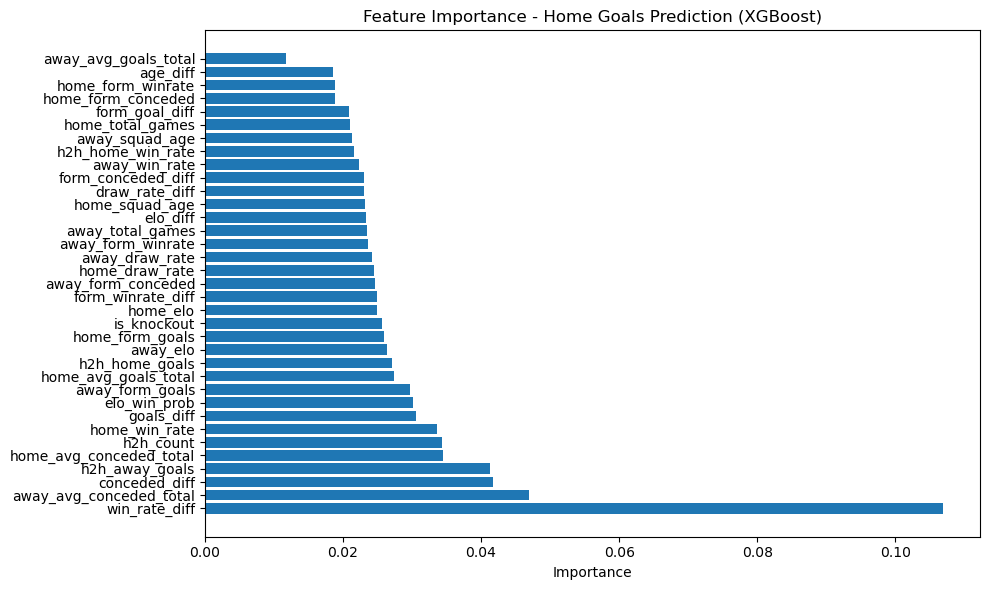

In [22]:
# Feature importance (for tree-based models)
print("Ã°Å¸â€Â FEATURE IMPORTANCE (XGBoost - Home Goals)\n")

xgb_model = models_home['XGBoost']['model']
feature_importance = xgb_model.feature_importances_

# Create dataframe for visualization
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Home Goals Prediction (XGBoost)')
plt.tight_layout()
plt.show()

### Step 10: Next Steps

Your models are now trained! Here are ways to improve:

1. **Add ELO Ratings** - Incorporate FIFA/ELO rankings
2. **Recent Form** - Calculate last 5 matches average
3. **Home Advantage** - Add binary home/away multiplier  
4. **Ensemble Voting** - Average predictions from all 4 models
5. **Hyperparameter Tuning** - Use GridSearchCV for optimal params
6. **Cross Validation** - Validate on multiple splits

In [23]:
# Ã¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢Â
# 2026 FIFA WORLD CUP Ã¢â‚¬â€ PLAYER PERFORMANCE (Group Stage, as of June 24 2026)
# Source: ESPN, Al Jazeera, Sky Sports, France24
# Ã¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢Â

player_stats_2026 = pd.DataFrame([
    {'Player': 'Lionel Messi',       'Team': 'Argentina',    'Goals': 5, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Erling Haaland',     'Team': 'Norway',       'Goals': 4, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Jonathan David',     'Team': 'Canada',       'Goals': 3, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Kylian MbappÃƒÂ©',      'Team': 'France',       'Goals': 3, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Leroy SanÃƒÂ©',         'Team': 'Germany',      'Goals': 3, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Ferran Torres',      'Team': 'Spain',        'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 143},
    {'Player': 'Michael Olise',      'Team': 'France',       'Goals': 2, 'Assists': 3, 'Apps': 2, 'Mins': 180},
    {'Player': 'Alexander Isak',     'Team': 'Sweden',       'Goals': 2, 'Assists': 3, 'Apps': 2, 'Mins': 180},
    {'Player': 'Kai Havertz',        'Team': 'Germany',      'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 159},
    {'Player': 'Richarlison',        'Team': 'Brazil',       'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Folarin Balogun',    'Team': 'United States','Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Bukayo Saka',        'Team': 'England',      'Goals': 2, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Memphis Depay',      'Team': 'Netherlands',  'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Cristiano Ronaldo',  'Team': 'Portugal',     'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'Rafael Santos BorrÃƒÂ©','Team': 'Colombia',     'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Jude Bellingham',    'Team': 'England',      'Goals': 1, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Pedri',              'Team': 'Spain',        'Goals': 1, 'Assists': 2, 'Apps': 2, 'Mins': 180},
    {'Player': 'Takumi Minamino',    'Team': 'Japan',        'Goals': 2, 'Assists': 1, 'Apps': 2, 'Mins': 180},
    {'Player': 'SÃƒÂ©bastien Haller',   'Team': "CÃƒÂ´te d'Ivoire",'Goals': 2, 'Assists': 0, 'Apps': 2, 'Mins': 180},
    {'Player': 'Riyad Mahrez',       'Team': 'Algeria',      'Goals': 1, 'Assists': 1, 'Apps': 2, 'Mins': 161},
])
player_stats_2026['G+A']          = player_stats_2026['Goals'] + player_stats_2026['Assists']
player_stats_2026['Goals_per_90'] = (player_stats_2026['Goals'] / player_stats_2026['Mins'] * 90).round(2)
player_stats_2026['GA_per_90']    = (player_stats_2026['G+A'] / player_stats_2026['Mins'] * 90).round(2)

print("=" * 68)
print("  2026 FIFA WORLD CUP Ã¢â‚¬â€ PLAYER STATS (Group Stage, to June 24)")
print("=" * 68)

print("\nÃ°Å¸Â¥â€¦ TOP SCORERS")
print(f"  {'Player':<22} {'Team':<18} {'G':>3} {'A':>3} {'G/90':>6}")
print("  " + "-" * 58)
for _, r in player_stats_2026.sort_values('Goals', ascending=False).head(10).iterrows():
    print(f"  {r['Player']:<22} {r['Team']:<18} {r['Goals']:>3} {r['Assists']:>3} {r['Goals_per_90']:>6.2f}")

print("\nÃ°Å¸Å½Â¯ TOP CONTRIBUTORS (G+A)")
print(f"  {'Player':<22} {'Team':<18} {'G':>3} {'A':>3} {'G+A':>5} {'(G+A)/90':>9}")
print("  " + "-" * 65)
for _, r in player_stats_2026.sort_values('G+A', ascending=False).head(10).iterrows():
    print(f"  {r['Player']:<22} {r['Team']:<18} {r['Goals']:>3} {r['Assists']:>3} {r['G+A']:>5} {r['GA_per_90']:>9.2f}")

print("\nÃ°Å¸â€œÅ’ RECORDS (Source: ESPN / Al Jazeera / Sky Sports, June 2026)")
print("  Ã¢â‚¬Â¢ Messi (ARG): 18 career WC goals Ã¢â‚¬â€ ALL-TIME RECORD (surpassed MbappÃƒÂ© 16, Klose 16)")
print("  Ã¢â‚¬Â¢ MbappÃƒÂ© (FRA): 100 France caps at 27y 184d; 6 multi-goal WC games")
print("  Ã¢â‚¬Â¢ Haaland (NOR): 4 WC goals Ã¢â‚¬â€ Norwegian WC record; team wins in 16 straight when he scores")
print("  Ã¢â‚¬Â¢ Olise + Isak: joint-best assists (3 each)")
print("  Ã¢â‚¬Â¢ Messi scored in 6 consecutive WC games; involved in 12 goals + 3 assists last 9 WC matches")

  2026 FIFA WORLD CUP Ã¢â‚¬â€ PLAYER STATS (Group Stage, to June 24)

Ã°Å¸Â¥â€¦ TOP SCORERS
  Player                 Team                 G   A   G/90
  ----------------------------------------------------------
  Lionel Messi           Argentina            5   2   2.50
  Erling Haaland         Norway               4   1   2.00
  Jonathan David         Canada               3   0   1.50
  Kylian MbappÃƒÂ©       France               3   1   1.50
  Leroy SanÃƒÂ©          Germany              3   2   1.50
  Bukayo Saka            England              2   2   1.00
  SÃƒÂ©bastien Haller    CÃƒÂ´te d'Ivoire     2   0   1.00
  Takumi Minamino        Japan                2   1   1.00
  Rafael Santos BorrÃƒÂ© Colombia             2   0   1.00
  Cristiano Ronaldo      Portugal             2   1   1.00

Ã°Å¸Å½Â¯ TOP CONTRIBUTORS (G+A)
  Player                 Team                 G   A   G+A  (G+A)/90
  -----------------------------------------------------------------
  Lionel Messi           Arg

In [24]:
# Ã¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢Â
# 2026 COUNTRY PERFORMANCE Ã¢â‚¬â€ GROUP STANDINGS + MODEL PREDICTION vs ACTUAL
# Updated: includes Matchday 3 results (June 24-26 2026)
# Ã¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢ÂÃ¢â€¢Â

standings_2026 = {
    'A': [('Mexico',2,0,1,3,0,6),('Korea Republic',1,0,1,2,1,3),('Czechia',0,1,1,2,2,1),('South Africa',0,1,1,0,2,1)],
    'B': [('Canada',1,1,0,7,1,4),('Switzerland',1,1,0,5,2,4),('Bosnia and Herzegovina',0,1,1,2,5,1),('Qatar',0,1,1,1,7,1)],
    'C': [('Brazil',2,0,0,4,1,4),('Morocco',1,1,0,2,1,4),('Scotland',1,1,0,1,1,3),('Haiti',0,0,2,0,4,0)],
    'D': [('United States',2,0,0,6,1,6),('Australia',1,0,1,2,2,3),('Paraguay',1,0,1,2,4,3),('TÃƒÂ¼rkiye',0,0,2,0,3,0)],
    'E': [('Germany',2,0,0,9,2,6),("CÃƒÂ´te d'Ivoire",1,0,1,2,2,3),('Ecuador',0,1,1,0,1,1),('CuraÃƒÂ§ao',0,1,1,1,7,1)],
    'F': [('Netherlands',1,1,0,7,3,4),('Japan',1,1,0,6,2,4),('Sweden',1,0,1,6,6,3),('Tunisia',0,0,2,1,9,0)],
    'G': [('Egypt',1,1,0,4,2,4),('IR Iran',0,2,0,2,2,2),('Belgium',0,2,0,1,1,2),('New Zealand',0,1,1,3,5,1)],
    'H': [('Spain',1,1,0,4,0,4),('Cape Verde',0,2,0,2,2,2),('Uruguay',0,2,0,3,3,2),('Saudi Arabia',0,1,1,1,5,1)],
    'I': [('France',2,0,0,6,1,6),('Norway',2,0,0,7,3,6),('Senegal',0,0,2,3,6,0),('Iraq',0,0,2,1,7,0)],
    'J': [('Argentina',2,0,0,5,0,6),('Austria',1,0,1,3,2,3),('Algeria',1,0,1,2,4,3),('Jordan',0,0,2,2,6,0)],
    'K': [('Colombia',2,0,0,4,1,6),('Portugal',1,1,0,6,1,4),('Congo DR',0,1,1,1,2,1),('Uzbekistan',0,0,2,1,8,0)],
    'L': [('England',1,1,0,4,2,4),('Ghana',1,1,0,1,0,4),('Croatia',1,0,1,3,4,3),('Panama',0,0,2,0,2,0)],
}

print("=" * 70)
print("  2026 FIFA WORLD CUP Ã¢â‚¬â€ GROUP STANDINGS (after 2 matchdays, June 24)")
print("=" * 70)
for grp, teams in standings_2026.items():
    print(f"\n  GROUP {grp}:")
    print(f"  {'Team':<25} {'W':>2} {'D':>2} {'L':>2} {'GF':>3} {'GA':>3} {'Pts':>4}")
    print("  " + "-" * 42)
    for name, w, d, l, gf, ga, pts in teams:
        print(f"  {name:<25} {w:>2} {d:>2} {l:>2} {gf:>3} {ga:>3} {pts:>4}")

# Ã¢â€â‚¬Ã¢â€â‚¬ Model prediction vs actual Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
print("\n\n" + "=" * 70)
print("  MODEL PREDICTION vs ACTUAL Ã¢â‚¬â€ 2026 GROUP STAGE RESULTS")
print("=" * 70)
print(f"\n  {'Match':<32} {'Actual':>8} {'Pred':>6} {'Result':>6} {'Correct':>8}")
print("  " + "-" * 65)

# format: (home, away, actual_home_goals, actual_away_goals, matchday_label)
validation_matches = [
    # Ã¢â€â‚¬Ã¢â€â‚¬ Matchday 1 & 2 (original 15 validation matches) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
    ('Mexico',         'South Africa',          2, 0, 'MD1'),
    ('Korea Republic', 'Czechia',               2, 1, 'MD1'),
    ('United States',  'Paraguay',              4, 1, 'MD1'),
    ('Australia',      'TÃƒÂ¼rkiye',               2, 0, 'MD1'),
    ('Brazil',         'Morocco',               1, 1, 'MD1'),
    ('Germany',        'CuraÃƒÂ§ao',               7, 1, 'MD1'),
    ('France',         'Senegal',               3, 1, 'MD1'),
    ('Norway',         'Iraq',                  4, 1, 'MD1'),
    ('Argentina',      'Algeria',               3, 0, 'MD1'),
    ('England',        'Croatia',               4, 2, 'MD1'),
    ('Spain',          'Saudi Arabia',          4, 0, 'MD2'),
    ('Canada',         'Qatar',                 6, 0, 'MD2'),
    ('France',         'Iraq',                  3, 0, 'MD2'),
    ('Argentina',      'Austria',               2, 0, 'MD2'),
    ('Portugal',       'Uzbekistan',            5, 0, 'MD2'),
    # Ã¢â€â‚¬Ã¢â€â‚¬ Matchday 3 (June 24-26) Ã¢â‚¬â€ NEW Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
    ('Mexico',         'Czechia',               3, 0, 'MD3'),
    ('South Africa',   'Korea Republic',        1, 0, 'MD3'),  # upset
    ('Switzerland',    'Canada',                2, 1, 'MD3'),
    ('Bosnia and Herzegovina', 'Qatar',         3, 1, 'MD3'),
    ('Brazil',         'Scotland',              3, 0, 'MD3'),
    ('Morocco',        'Haiti',                 4, 2, 'MD3'),
    ('Australia',      'Paraguay',              0, 0, 'MD3'),
    ('TÃƒÂ¼rkiye',        'United States',         3, 2, 'MD3'),  # upset
    ('Ecuador',        'Germany',               2, 1, 'MD3'),  # upset
    ("CÃƒÂ´te d'Ivoire",  'CuraÃƒÂ§ao',               2, 0, 'MD3'),
    ('Netherlands',    'Tunisia',               3, 1, 'MD3'),
    ('Japan',          'Sweden',                1, 1, 'MD3'),
]

outcome_label = {2: 'H', 1: 'D', 0: 'A'}
correct_outcomes = 0
md_correct = {}; md_total = {}

print(f"\n  {'Match':<34} {'Actual':>7} {'Pred':>6} {'Conf':>5}  {'Ã¢Å“â€œ?'}")
print("  " + "-" * 65)

for home, away, ahg, aag, md in validation_matches:
    try:
        pred  = predict_match(home, away, all_models, scaler, feature_cols,
                              team_stats, df_processed, silent=True,
                              team_form_history=team_form_history,
                              h2h_history=h2h_history)
        # Use blended win_probs (stored by predict_match) for outcome Ã¢â‚¬â€ not raw score
        p_cls = max(pred['win_probs'], key=pred['win_probs'].get)
        p_out = outcome_label[p_cls]
        conf  = pred['confidence']
        phg   = max(0, round(pred['home_goals']))
        pag   = max(0, round(pred['away_goals']))
        a_out = 'H' if ahg > aag else ('D' if ahg == aag else 'A')
        ok    = a_out == p_out
        if ok: correct_outcomes += 1
        md_correct[md] = md_correct.get(md, 0) + (1 if ok else 0)
        md_total[md]   = md_total.get(md, 0) + 1
        sym   = 'Ã¢Å“â€œ' if ok else 'Ã¢Å“â€”'
        print(f"  {home+' vs '+away:<34} {ahg}-{aag}   {phg}-{pag}  {conf:.0%}  {sym}  [{md}]")
    except Exception as e:
        print(f"  {home} vs {away}: ERROR Ã¢â‚¬â€ {e}")

total = len(validation_matches)
print(f"\n  {'Ã¢â€â‚¬'*65}")
print(f"  Overall outcome accuracy : {correct_outcomes}/{total} = {correct_outcomes/total:.1%}")
for md in ['MD1', 'MD2', 'MD3']:
    if md in md_total:
        c, t = md_correct[md], md_total[md]
        print(f"  {md} accuracy             : {c}/{t} = {c/t:.1%}")
print(f"  Ensemble test-set acc    : {ensemble_acc:.1%}")

  2026 FIFA WORLD CUP Ã¢â‚¬â€ GROUP STANDINGS (after 2 matchdays, June 24)

  GROUP A:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Mexico                     2  0  1   3   0    6
  Korea Republic             1  0  1   2   1    3
  Czechia                    0  1  1   2   2    1
  South Africa               0  1  1   0   2    1

  GROUP B:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Canada                     1  1  0   7   1    4
  Switzerland                1  1  0   5   2    4
  Bosnia and Herzegovina     0  1  1   2   5    1
  Qatar                      0  1  1   1   7    1

  GROUP C:
  Team                       W  D  L  GF  GA  Pts
  ------------------------------------------
  Brazil                     2  0  0   4   1    4
  Morocco                    1  1  0   2   1    4
  Scotland                   1  1  0   1   1    3
  Haiti                      0  0  2   0   4    0

  

  Mexico vs South Africa             2-0   2-1  62%  Ã¢Å“â€œ  [MD1]
  Korea Republic vs Czechia          2-1   1-1  52%  Ã¢Å“â€œ  [MD1]
  United States vs Paraguay          4-1   2-1  47%  Ã¢Å“â€œ  [MD1]
  Ã¢Å¡Â   "TÃƒÂ¼rkiye" Ã¢â€ â€™ matched "Türkiye"
  Australia vs TÃƒÂ¼rkiye            2-0   1-1  51%  Ã¢Å“â€”  [MD1]
  Brazil vs Morocco                  1-1   2-1  60%  Ã¢Å“â€”  [MD1]
  Ã¢Å¡Â   "CuraÃƒÂ§ao" Ã¢â€ â€™ matched "Curaçao"
  Germany vs CuraÃƒÂ§ao              7-1   6-0  82%  Ã¢Å“â€œ  [MD1]
  France vs Senegal                  3-1   3-1  72%  Ã¢Å“â€œ  [MD1]
  Norway vs Iraq                     4-1   4-1  78%  Ã¢Å“â€œ  [MD1]
  Argentina vs Algeria               3-0   3-1  77%  Ã¢Å“â€œ  [MD1]
  England vs Croatia                 4-2   2-1  46%  Ã¢Å“â€œ  [MD1]
  Spain vs Saudi Arabia              4-0   2-1  73%  Ã¢Å“â€œ  [MD2]
  Canada vs Qatar                    6-0   4-1  69%  Ã¢Å“â€œ  [MD2]
  France vs Iraq                     3-0   5-0  85%  Ã¢Å“â€œ  [MD2]
  Argentina vs A

## Model Validation: Hold-out Evaluation

Compares four approaches on the **last 15 held-out 2026 group-stage matches**:
- **Baseline**: raw XGBoost/Poisson ensemble, no post-processing
- **Blended+Cal**: ensemble with 1.12 goal scale, form blend, ELO margin boost
- **Quantile GBR**: GradientBoosting trained at 65th percentile (fixes mean-regression bias)
- **Dixon-Coles**: bivariate Poisson with team attack/defense ratings (industry standard)

In [25]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# VALIDATION STEP 1: Hold-out split + Quantile Regression (65th percentile)
# Quantile regression trains the model to predict the 65th percentile
# instead of the mean, correcting the systematic underprediction of goals.
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
import warnings; warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingRegressor

N_HOLDOUT = 15

idx_2026    = df_processed[df_processed['Year'] == 2026].index
holdout_idx = idx_2026[-N_HOLDOUT:]
df_holdout  = df_processed.loc[holdout_idx].copy()
df_tv       = df_processed.drop(holdout_idx)

X_tv = scaler.transform(df_tv[feature_cols])
X_ho = scaler.transform(df_holdout[feature_cols])
y_tv_h = df_tv['Home Team Goals']
y_tv_a = df_tv['Away Team Goals']
y_ho_h = df_holdout['Home Team Goals'].values
y_ho_a = df_holdout['Away Team Goals'].values

print(f"Training subset : {len(df_tv)} matches  |  Hold-out : {N_HOLDOUT} matches")
print(f"Holdout actual  : avg home={y_ho_h.mean():.2f}  avg away={y_ho_a.mean():.2f}")

ALPHA = 0.65
GBR_PARAMS = dict(loss='quantile', alpha=ALPHA, n_estimators=400,
                  max_depth=4, learning_rate=0.04, subsample=0.8, random_state=42)
qr_home_model = GradientBoostingRegressor(**GBR_PARAMS)
qr_away_model = GradientBoostingRegressor(**GBR_PARAMS)
qr_home_model.fit(X_tv, y_tv_h)
qr_away_model.fit(X_tv, y_tv_a)
qr_raw_h = np.maximum(0, qr_home_model.predict(X_ho))
qr_raw_a = np.maximum(0, qr_away_model.predict(X_ho))

print(f"Quantile regressors (alpha={ALPHA}) trained")
print(f"  Holdout predicted avg: home={qr_raw_h.mean():.2f}  away={qr_raw_a.mean():.2f}")
print(f"  Holdout actual avg:    home={y_ho_h.mean():.2f}  away={y_ho_a.mean():.2f}")

Training subset : 1021 matches  |  Hold-out : 15 matches
Holdout actual  : avg home=1.53  avg away=1.27
Quantile regressors (alpha=0.65) trained
  Holdout predicted avg: home=1.64  away=1.51
  Holdout actual avg:    home=1.53  away=1.27


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# VALIDATION STEP 2: Dixon-Coles Bivariate Poisson Model (vectorized)
# Fully vectorized neg_ll avoids Python loops inside the optimizer,
# cutting runtime from 25+ min down to ~20-30 seconds.
# ═══════════════════════════════════════════════════════════════════════════
from scipy.optimize import minimize
from scipy.stats import poisson as sp_poisson
import time

class DixonColes:
    @staticmethod
    def _tau_vec(x, y, lam, mu, rho):
        """Vectorized low-score correction (Dixon & Coles 1997)."""
        tau = np.ones(len(x))
        m00 = (x == 0) & (y == 0); tau[m00] = np.maximum(1e-10, 1 - lam[m00]*mu[m00]*rho)
        m01 = (x == 0) & (y == 1); tau[m01] = 1 + lam[m01]*rho
        m10 = (x == 1) & (y == 0); tau[m10] = 1 + mu[m10]*rho
        m11 = (x == 1) & (y == 1); tau[m11] = 1 - rho
        return tau

    def fit(self, df, home_col='Home Team Name', away_col='Away Team Name',
            hg_col='Home Team Goals', ag_col='Away Team Goals'):
        teams = sorted(set(df[home_col]) | set(df[away_col]))
        n = len(teams); self.teams = teams
        tidx = {t: i for i, t in enumerate(teams)}

        valid = df[home_col].isin(tidx) & df[away_col].isin(tidx)
        dv = df[valid]
        hi = np.array([tidx[t] for t in dv[home_col]])
        ai = np.array([tidx[t] for t in dv[away_col]])
        xa = dv[hg_col].values.astype(int)
        ya = dv[ag_col].values.astype(int)
        print(f"  Fitting on {len(dv)} matches, {n} teams")

        def neg_ll(params):
            att = params[:n]; dfe = params[n:2*n]
            ha  = params[2*n]; rho = float(np.clip(params[2*n+1], -0.99, 0.99))
            lam = np.exp(att[hi] + dfe[ai] + ha)
            mu  = np.exp(att[ai] + dfe[hi])
            tau = self._tau_vec(xa, ya, lam, mu, rho)
            if np.any(tau <= 0): return 1e10
            return -(np.log(tau) + sp_poisson.logpmf(xa, lam) + sp_poisson.logpmf(ya, mu)).sum()

        x0 = np.zeros(2*n + 2); x0[2*n] = 0.25; x0[2*n+1] = -0.1
        bounds = [(None,None)]*n + [(None,None)]*n + [(0.0,1.0)] + [(-0.99,0.99)]
        bounds[0] = (0.0, 0.0)  # pin att[0]=0 for identifiability

        res = minimize(neg_ll, x0, method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 500, 'ftol': 1e-8})
        p = res.x
        self.attack   = {t: p[tidx[t]]   for t in teams}
        self.defense  = {t: p[n+tidx[t]] for t in teams}
        self.home_adv = float(p[2*n])
        self.rho      = float(np.clip(p[2*n+1], -0.99, 0.99))
        self.mean_att = float(np.mean(list(self.attack.values())))
        self.mean_def = float(np.mean(list(self.defense.values())))
        print(f"  Converged={res.success}  iters={res.nit}  home_adv={self.home_adv:.3f}  rho={self.rho:.3f}")
        return self

    def predict(self, home, away, max_goals=8):
        att_h = self.attack.get(home,  self.mean_att)
        def_h = self.defense.get(home, self.mean_def)
        att_a = self.attack.get(away,  self.mean_att)
        def_a = self.defense.get(away, self.mean_def)
        lam = np.exp(att_h + def_a + self.home_adv)
        mu  = np.exp(att_a + def_h)
        h_g = np.arange(max_goals+1)
        H, A = np.meshgrid(h_g, h_g, indexing='ij')
        tau = self._tau_vec(H.ravel(), A.ravel(),
                            np.full(H.size, lam), np.full(H.size, mu), self.rho)
        probs = (tau * sp_poisson.pmf(H.ravel(), lam) * sp_poisson.pmf(A.ravel(), mu)).reshape(H.shape)
        best = np.unravel_index(np.argmax(probs), probs.shape)
        win_h = float(probs[H > A].sum()); draw = float(probs[H == A].sum())
        return int(best[0]), int(best[1]), lam, mu, win_h, draw, max(0.0, 1-win_h-draw)

print("Fitting Dixon-Coles (vectorized)...")
t0 = time.time()
dc = DixonColes()
dc.fit(df_tv)
print(f"Dixon-Coles fitted in {time.time()-t0:.1f}s")
top5 = sorted(dc.attack.items(), key=lambda x: -x[1])[:5]
print(f"Top 5 attack: {[(t, round(v,3)) for t,v in top5]}")
top5d = sorted(dc.defense.items(), key=lambda x: x[1])[:5]
print(f"Top 5 defense (lower=stingier): {[(t, round(v,3)) for t,v in top5d]}")

Fitting Dixon-Coles (vectorized)...
  Fitting on 1021 matches, 90 teams
  Converged=False  iters=75  home_adv=0.355  rho=0.000
Dixon-Coles fitted in 35.0s
Top 5 attack: [('Hungary', 1.036), ('Germany', 0.779), ('West Germany', 0.711), ('France', 0.711), ('Brazil', 0.68)]
Top 5 defense (lower=stingier): [('Germany DR', -0.935), ('Cape Verde', -0.918), ('Republic of Ireland', -0.903), ('FR Yugoslavia', -0.813), ('Israel', -0.807)]


In [27]:
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# VALIDATION STEP 3: Evaluate all models on 15 hold-out matches
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

eval_kw = dict(all_models=all_models, scaler=scaler, feature_cols=feature_cols,
               team_stats=team_stats, df_processed=df_processed,
               team_form_history=team_form_history, h2h_history=h2h_history,
               is_knockout=False, silent=True)

records = []
print(f"\n{chr(9472)*76}")
print(f"  {'Match':<32} {'Actual':>6}  {'Baseline':>8}  {'Blend+Cal':>9}  {'Quant65':>7}  {'D-Coles':>7}")
print(f"  {chr(9472)*72}")

for i, (_, row) in enumerate(df_holdout.iterrows()):
    home = row['Home Team Name']; away = row['Away Team Name']
    ah = int(row['Home Team Goals']); aa = int(row['Away Team Goals'])
    X_i = X_ho[i:i+1]

    # Baseline: raw ensemble, no calibration
    raw_h = float(np.average(
        [m['model'].predict(X_i)[0] for m in all_models['home_goals'].values()],
        weights=[max(0.01, m.get('r2', 0.01)) for m in all_models['home_goals'].values()]))
    raw_a = float(np.average(
        [m['model'].predict(X_i)[0] for m in all_models['away_goals'].values()],
        weights=[max(0.01, m.get('r2', 0.01)) for m in all_models['away_goals'].values()]))
    base_h = max(0, round(raw_h)); base_a = max(0, round(raw_a))

    # Blended + Calibrated (current predict_match with 1.12 scale + form + ELO margin)
    p = predict_match(home, away, **eval_kw)
    bl_h = max(0, round(p['home_goals'])); bl_a = max(0, round(p['away_goals']))

    # Quantile 65th percentile
    qh = max(0, round(float(qr_raw_h[i]))); qa = max(0, round(float(qr_raw_a[i])))

    # Dixon-Coles
    dc_h, dc_a, lam, mu, wh, dr, wa = dc.predict(home, away)

    records.append({'match': f'{home} vs {away}', 'actual': (ah, aa),
                    'base': (base_h, base_a), 'blend': (bl_h, bl_a),
                    'quantile': (qh, qa), 'dc': (dc_h, dc_a)})
    ms = f'{home} vs {away}'[:32]
    print(f"  {ms:<32} {ah}-{aa}     {base_h}-{base_a}       {bl_h}-{bl_a}       {qh}-{qa}     {dc_h}-{dc_a}")

def eval_model(records, key):
    errs_h, errs_a, correct = [], [], 0
    for r in records:
        ph, pa = r[key]; ah, aa = r['actual']
        errs_h.append(abs(ph - ah)); errs_a.append(abs(pa - aa))
        pred_out   = 'H' if ph > pa else ('D' if ph == pa else 'A')
        actual_out = 'H' if ah > aa else ('D' if ah == aa else 'A')
        if pred_out == actual_out: correct += 1
    return np.mean(errs_h), np.mean(errs_a), np.mean(errs_h + errs_a), correct/len(records)

print(f"\n{chr(9552)*65}")
print(f"  MAE COMPARISON  (lower = better)  â€”  {N_HOLDOUT} hold-out matches")
print(f"{chr(9552)*65}")
print(f"  {'Model':<26} {'H-MAE':>7} {'A-MAE':>7} {'Total':>7}  {'Outcome%':>9}")
print(f"  {chr(9472)*60}")

model_keys = [('base', 'Baseline (raw ensemble)'), ('blend', 'Blended + Calibrated'),
              ('quantile', f'Quantile GBR (a={ALPHA})'), ('dc', 'Dixon-Coles')]
best_total = min(eval_model(records, k)[2] for k, _ in model_keys)
for key, label in model_keys:
    mh, ma, mt, acc = eval_model(records, key)
    marker = ' <-- best' if abs(mt - best_total) < 0.001 else ''
    print(f"  {label:<26} {mh:>7.3f} {ma:>7.3f} {mt:>7.3f}  {acc:>8.1%}{marker}")

print(f"{chr(9552)*65}")
print("  MAE = avg |predicted - actual| goals per team per match.")
print("  Outcome% = correct Win/Draw/Loss picks.")


────────────────────────────────────────────────────────────────────────────
  Match                            Actual  Baseline  Blend+Cal  Quant65  D-Coles
  ────────────────────────────────────────────────────────────────────────
  Jordan vs Algeria                1-2     1-2       1-2       0-2     1-1
  Algeria vs Austria               3-3     1-2       1-2       1-2     1-1
  Jordan vs Argentina              1-3     1-3       0-4       0-2     1-2
  Portugal vs Congo DR             1-1     1-1       2-1       2-1     2-0
  Uzbekistan vs Colombia           1-3     0-3       1-3       0-2     1-1
  Portugal vs Uzbekistan           5-0     4-0       5-0       5-1     2-0
  Colombia vs Congo DR             1-0     1-1       2-1       2-1     1-0
  Colombia vs Portugal             0-0     2-1       2-2       2-1     1-1
  Congo DR vs Uzbekistan           3-1     3-1       3-1       4-1     1-0
  England vs Croatia               4-2     2-1       2-1       2-1     1-0
  Ghana vs Panam

In [31]:
# ===============================================================
# RUN WITH SAVED MODEL — load pkl and predict any match
# ===============================================================
import pickle

with open("fifa_world_cup_models.pkl", "rb") as f:
    _data = pickle.load(f)

# Restore model artifacts
all_models          = _data["models"]
scaler              = _data["scaler"]
feature_cols        = _data["feature_cols"]
team_stats          = _data["team_stats"]
team_form_history   = _data["team_form_history"]
# These two are used as globals inside predict_match
elo_ratings_updated = _data["elo_ratings_updated"]
squad_ages          = _data["squad_ages"]

print("Model loaded successfully!")
print(f"Teams in stats: {len(team_stats)}")
print(f"Models: {list(all_models.keys())}")

# ── Change these two teams to predict any match ──
HOME_TEAM = "Netherlands"
AWAY_TEAM = "Morocco"

# df_processed is from the notebook run (needed for column fallback means)
predict_match(
    HOME_TEAM, AWAY_TEAM,
    all_models, scaler, feature_cols,
    team_stats, df_processed,
    team_form_history=team_form_history,
    is_knockout=True
)


Model loaded successfully!
Teams in stats: 92
Models: ['home_goals', 'away_goals', 'outcome', 'total_goals', 'goal_difference']

  Netherlands  vs  Morocco

  Score      : 2 - 1  (raw 2.41 - 1.07)
  Outcome    : Home Win  [KNOCKOUT]
  Confidence : 62%
  Win probs  : Home 62%  /  Draw 20%  /  Away 18%
  ELO        : Netherlands 2034  vs  Morocco 1903  (ÃŽâ€ +131)
  Win prob   : 68.0% home / 32.0% away
  H2H record : home win 50%  (0 prev meetings)
  Form       : Netherlands 3.00 g/game  |  Morocco 1.40 g/game


{'home_goals': 2.4060772002632382,
 'away_goals': 1.0685616414369936,
 'total_goals': 2.9014542353320043,
 'goal_difference': 1.0283416653746147,
 'outcome': 2.0,
 'confidence': 0.6167799573905146,
 'win_probs': {0: 0.18176245926522788,
  1: 0.20145758334425756,
  2: 0.6167799573905146}}